<a href="https://colab.research.google.com/github/Tashya924/ML-research-on-credit-risk-analysis/blob/modelresults02/ml_credit_report_intern.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install -q lightgbm imbalanced-learn scikit-plot kagglehub[pandas-datasets]

In [3]:
import numpy as np
import pandas as pd
import kagglehub
from kagglehub import KaggleDatasetAdapter
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import RandomOverSampler

df = kagglehub.dataset_load(
    KaggleDatasetAdapter.PANDAS,
    "uciml/default-of-credit-card-clients-dataset",
    "UCI_Credit_Card.csv"
)

target = "default.payment.next.month"
X = df.drop(columns=["ID", target])
y = df[target]

# --- 1. Original Methodology (Leaky) ---
ros = RandomOverSampler(random_state=42)
X_res, y_res = ros.fit_resample(X, y)
X_train_leaky, X_test_leaky, y_train_leaky, y_test_leaky = train_test_split(
    X_res, y_res, test_size=0.25, random_state=42, shuffle=True
)
scaler_leaky = StandardScaler()
X_train_leaky_sc = scaler_leaky.fit_transform(X_train_leaky)
X_test_leaky_sc = scaler_leaky.transform(X_test_leaky)

# --- 2. Corrected Methodology (No Leakage) ---
X_train_raw, X_test_corr, y_train_raw, y_test_corr = train_test_split(
    X, y, test_size=0.25, random_state=42, shuffle=True
)
# Oversample ONLY the training set
X_train_corr, y_train_corr = ros.fit_resample(X_train_raw, y_train_raw)
scaler_corr = StandardScaler()
X_train_corr_sc = scaler_corr.fit_transform(X_train_corr)
X_test_corr_sc = scaler_corr.transform(X_test_corr)

print("Leaky Train Shape:", X_train_leaky.shape)
print("Corrected Train Shape:", X_train_corr.shape)

100%|██████████| 0.98M/0.98M [00:00<00:00, 22.2MB/s]

Extracting zip of UCI_Credit_Card.csv...


Leaky Train Shape: (35046, 23)
Corrected Train Shape: (34982, 23)


In [4]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.neural_network import MLPClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, roc_auc_score

models_dict = {
    "Logistic Regression": LogisticRegression(max_iter=500),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "KNN": KNeighborsClassifier(),
    "Random Forest": RandomForestClassifier(random_state=42, n_estimators=100),
    "Naive Bayes": GaussianNB(),
    "LGBM": LGBMClassifier(random_state=42, verbose=-1),
    "AdaBoost": AdaBoostClassifier(random_state=42),
    "Gradient Boost": GradientBoostingClassifier(random_state=42),
    "LDA": LinearDiscriminantAnalysis(),
    "MLP": MLPClassifier(max_iter=500, random_state=42)
}

all_results = []

for scenario in ["Leaky", "Corrected"]:
    if scenario == "Leaky":
        xtr, xte, ytr, yte = X_train_leaky, X_test_leaky, y_train_leaky, y_test_leaky
        xtr_sc, xte_sc = X_train_leaky_sc, X_test_leaky_sc
    else:
        xtr, xte, ytr, yte = X_train_corr, X_test_corr, y_train_corr, y_test_corr
        xtr_sc, xte_sc = X_train_corr_sc, X_test_corr_sc

    for name, model in models_dict.items():
        use_sc = name in ["Logistic Regression", "KNN", "LDA", "MLP"]
        model.fit(xtr_sc if use_sc else xtr, ytr)
        preds = model.predict(xte_sc if use_sc else xte)
        probs = model.predict_proba(xte_sc if use_sc else xte)[:,1]

        all_results.append({
            "Algorithm": name, "Scenario": scenario,
            "Precision": precision_score(yte, preds), "Recall": recall_score(yte, preds),
            "F1": f1_score(yte, preds), "Accuracy": accuracy_score(yte, preds),
            "ROC_AUC": roc_auc_score(yte, probs)
        })

res_df = pd.DataFrame(all_results)
display(res_df.head())

,Algorithm,Scenario,Precision,Recall,F1,Accuracy,ROC_AUC
0,Logistic Regression,Leaky,0.681502,0.634658,0.657246,0.667779,0.718882
1,Decision Tree,Leaky,0.820289,0.959918,0.884627,0.874337,0.874119
2,KNN,Leaky,0.710817,0.823810,0.763154,0.743366,0.825009
3,Random Forest,Leaky,0.904389,0.966399,0.934367,0.931861,0.978697
4,Naive Bayes,Leaky,0.526905,0.938598,0.674925,0.546225,0.673258


In [5]:
import matplotlib.pyplot as plt

from sklearn.metrics import precision_recall_curve

def threshold_plot(model,X,y,title):

    probs = model.predict_proba(X)[:,1]

    precision, recall, thresholds = precision_recall_curve(
        y,
        probs
    )

    precision = precision[:-1]
    recall = recall[:-1]

    f1 = (
        2 * precision * recall /
        (precision + recall + 1e-10)
    )

    queue_rate = [
        np.mean(probs >= t)
        for t in thresholds
    ]

    best_idx = np.argmax(f1)
    best_thresh = thresholds[best_idx]

    plt.figure(figsize=(10,6))

    plt.plot(thresholds,precision,label="Precision")
    plt.plot(thresholds,recall,label="Recall")
    plt.plot(thresholds,f1,label="F1 Score")
    plt.plot(thresholds,queue_rate,label="Queue Rate")

    plt.axvline(
        best_thresh,
        linestyle="--"
    )

    plt.xlabel("Threshold")
    plt.ylabel("Score")
    plt.title(title)
    plt.legend()
    plt.show()

    print("Best Threshold:",round(best_thresh,4))
    print("Best F1:",round(f1[best_idx],4))

    return best_thresh

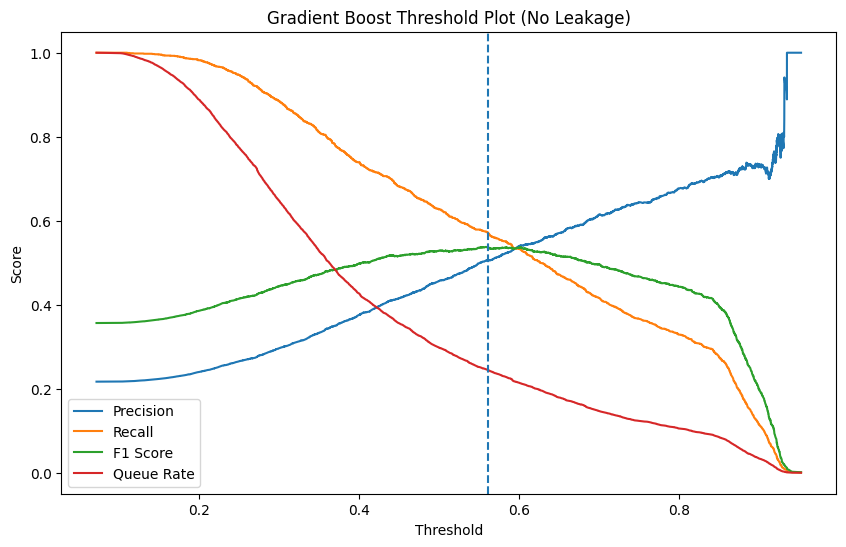

Best Threshold: 0.5603
Best F1: 0.5378


In [6]:
gb = models_dict["Gradient Boost"]

gb_thresh = threshold_plot(
    gb,
    X_test_corr_sc if "Gradient Boost" in ["Logistic Regression", "KNN", "LDA", "MLP"] else X_test_corr,
    y_test_corr,
    "Gradient Boost Threshold Plot (No Leakage)"
)

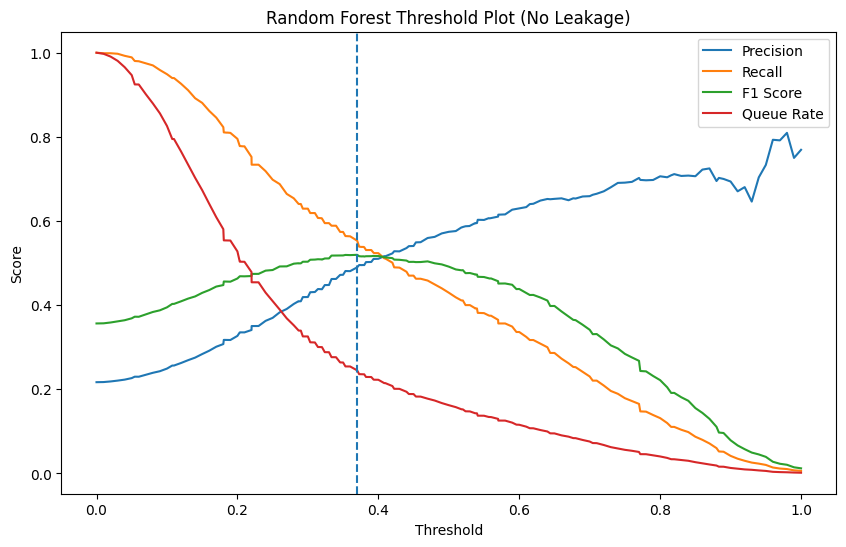

Best Threshold: 0.37
Best F1: 0.5196


In [7]:
rf = models_dict["Random Forest"]

rf_thresh = threshold_plot(
    rf,
    X_test_corr,
    y_test_corr,
    "Random Forest Threshold Plot (No Leakage)"
)

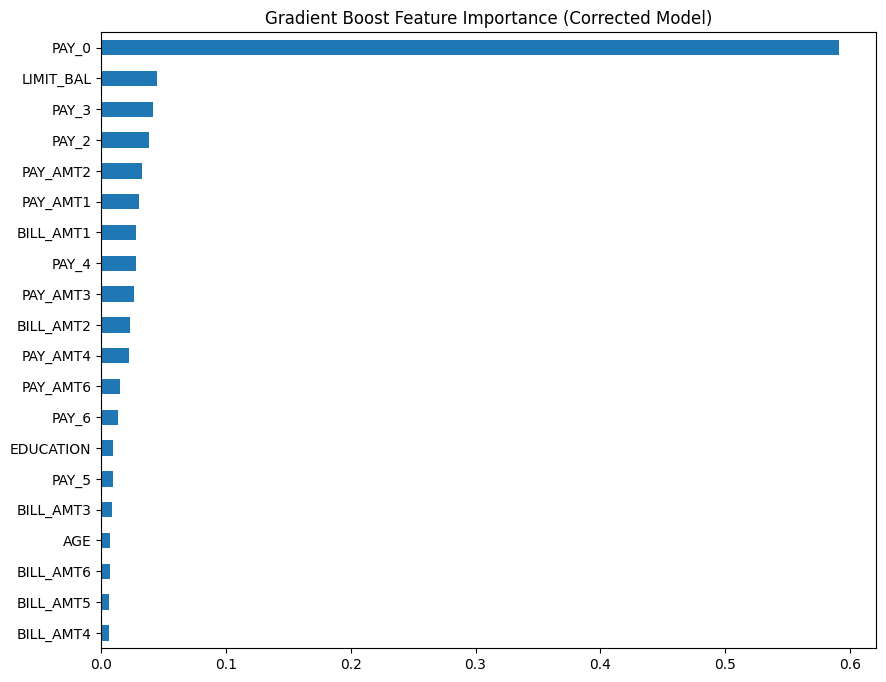

,0
PAY_0,0.591551
LIMIT_BAL,0.044554
PAY_3,0.041631
PAY_2,0.038606
PAY_AMT2,0.032291
PAY_AMT1,0.030528
BILL_AMT1,0.028049
PAY_4,0.027868
PAY_AMT3,0.026352
BILL_AMT2,0.023002


In [8]:
gb = models_dict["Gradient Boost"]
imp = pd.Series(
    gb.feature_importances_,
    index=X.columns
).sort_values()

plt.figure(figsize=(10, 8))
imp.tail(20).plot(kind="barh")
plt.title("Gradient Boost Feature Importance (Corrected Model)")
plt.show()

display(imp.sort_values(ascending=False).head(20))

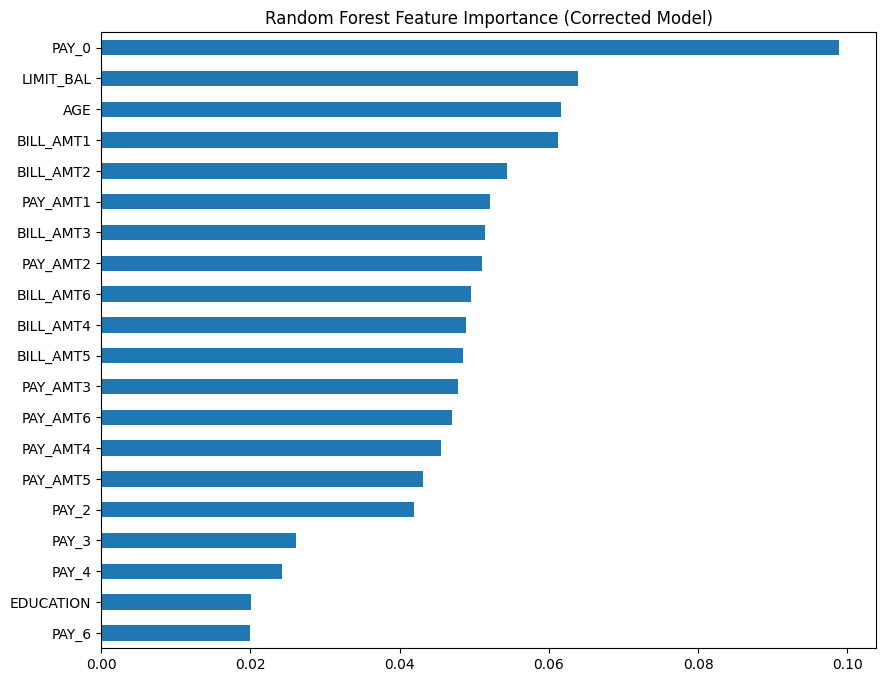

,0
PAY_0,0.098905
LIMIT_BAL,0.063904
AGE,0.061673
BILL_AMT1,0.061203
BILL_AMT2,0.054369
PAY_AMT1,0.052070
BILL_AMT3,0.051476
PAY_AMT2,0.051026
BILL_AMT6,0.049607
BILL_AMT4,0.048847


In [9]:
rf = models_dict["Random Forest"]
imp = pd.Series(
    rf.feature_importances_,
    index=X.columns
).sort_values()

plt.figure(figsize=(10, 8))
imp.tail(20).plot(kind="barh")
plt.title("Random Forest Feature Importance (Corrected Model)")
plt.show()

display(imp.sort_values(ascending=False).head(20))

In [10]:
import numpy as np
import pandas as pd
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.neural_network import MLPClassifier
from lightgbm import LGBMClassifier

# Define parameter grids
# Note: LDA is split into a list of dictionaries to prevent pairing 'svd' with shrinkage
param_grids = {
    "Logistic Regression": {
        "estimator": LogisticRegression(random_state=42),
        "params": {"C": [0.01, 0.1, 1, 10], "max_iter": [500, 1000], "solver": ["lbfgs", "liblinear"]},
        "scaled": True,
    },
    "Decision Tree": {
        "estimator": DecisionTreeClassifier(random_state=42),
        "params": {"max_depth": [5, 10, 20, None], "min_samples_split": [2, 5, 10], "criterion": ["gini", "entropy"]},
        "scaled": False,
    },
    "KNN": {
        "estimator": KNeighborsClassifier(),
        "params": {"n_neighbors": [3, 5, 7, 11], "weights": ["uniform", "distance"], "metric": ["euclidean", "manhattan"]},
        "scaled": True,
    },
    "Random Forest": {
        "estimator": RandomForestClassifier(random_state=42),
        "params": {"n_estimators": [100, 200], "max_depth": [5, 10, None], "min_samples_split": [2, 5]},
        "scaled": False,
    },
    "Naive Bayes": {
        "estimator": GaussianNB(),
        "params": {"var_smoothing": [1e-9, 1e-8, 1e-7, 1e-6, 1e-5]},
        "scaled": False,
    },
    "LGBM": {
        "estimator": LGBMClassifier(random_state=42, verbose=-1),
        "params": {"n_estimators": [100, 200], "learning_rate": [0.05, 0.1], "max_depth": [3, 5, 7], "num_leaves": [31, 50]},
        "scaled": False,
    },
    "AdaBoost": {
        "estimator": AdaBoostClassifier(random_state=42),
        "params": {"n_estimators": [50, 100, 200], "learning_rate": [0.01, 0.1, 1.0]},
        "scaled": False,
    },
    "Gradient Boost": {
        "estimator": GradientBoostingClassifier(random_state=42),
        "params": {"n_estimators": [100, 200], "learning_rate": [0.05, 0.1], "max_depth": [3, 5]},
        "scaled": False,
    },
    "LDA": {
        "estimator": LinearDiscriminantAnalysis(),
        "params": [
            {"solver": ["svd"], "shrinkage": [None]},
            {"solver": ["lsqr"], "shrinkage": [None, 0.1, 0.5, 1.0]}
        ],
        "scaled": True,
    },
    "MLP": {
        "estimator": MLPClassifier(random_state=42),
        "params": {"hidden_layer_sizes": [(100,), (100, 50), (50, 25)], "max_iter": [500, 1000], "learning_rate_init": [0.001, 0.01]},
        "scaled": True,
    },
}

best_params_all = {}

# Hyperparameter Tuning Loop
for name, config in param_grids.items():
    print(f"Tuning {name}...", end=" ")

    # Choose the correct feature set based on scaling requirements
    xtr = X_train_corr_sc if config["scaled"] else X_train_corr

    search = GridSearchCV(
        config["estimator"],
        config["params"],
        scoring="f1",
        cv=5,
        n_jobs=-1,
        error_score="raise"
    )

    try:
        search.fit(xtr, y_train_corr)
        best_params_all[name] = {
            "params": search.best_params_,
            "best_f1_cv": round(search.best_score_, 4)
        }
        print(f"Best F1={search.best_score_:.4f} | Params: {search.best_params_}")
    except Exception as e:
        print(f"FAILED — {e}")
        best_params_all[name] = {
            "params": "error",
            "best_f1_cv": np.nan,  # Ensures sorting won't break if an unexpected error occurs
            "error": str(e)
        }

# Generate and Display Results Table
print("\n" + "=" * 70)
print("SUMMARY")
print("=" * 70)

summary_df = pd.DataFrame([
    {
        "Model": name,
        "Best CV F1": info.get("best_f1_cv", np.nan),
        "Best Params": str(info.get("params", "N/A"))
    }
    for name, info in best_params_all.items()
]).sort_values("Best CV F1", ascending=False)

display(summary_df)

Tuning Logistic Regression... Best F1=0.6686 | Params: {'C': 10, 'max_iter': 500, 'solver': 'lbfgs'}
Tuning Decision Tree... Best F1=0.8979 | Params: {'criterion': 'entropy', 'max_depth': None, 'min_samples_split': 2}
Tuning KNN... Best F1=0.8650 | Params: {'metric': 'euclidean', 'n_neighbors': 11, 'weights': 'distance'}
Tuning Random Forest... Best F1=0.9431 | Params: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
Tuning Naive Bayes... Best F1=0.6687 | Params: {'var_smoothing': 1e-09}
Tuning LGBM... Best F1=0.8218 | Params: {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 200, 'num_leaves': 50}
Tuning AdaBoost... Best F1=0.6772 | Params: {'learning_rate': 1.0, 'n_estimators': 200}
Tuning Gradient Boost... Best F1=0.7745 | Params: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200}
Tuning LDA... Best F1=0.6645 | Params: {'shrinkage': None, 'solver': 'svd'}
Tuning MLP... Best F1=0.8176 | Params: {'hidden_layer_sizes': (100, 50), 'learning_rate_init': 0.00

,Model,Best CV F1,Best Params
3,Random Forest,0.9431,"{'max_depth': None, 'min_samples_split': 2, 'n..."
1,Decision Tree,0.8979,"{'criterion': 'entropy', 'max_depth': None, 'm..."
2,KNN,0.8650,"{'metric': 'euclidean', 'n_neighbors': 11, 'we..."
5,LGBM,0.8218,"{'learning_rate': 0.1, 'max_depth': 7, 'n_esti..."
9,MLP,0.8176,"{'hidden_layer_sizes': (100, 50), 'learning_ra..."
7,Gradient Boost,0.7745,"{'learning_rate': 0.1, 'max_depth': 5, 'n_esti..."
6,AdaBoost,0.6772,"{'learning_rate': 1.0, 'n_estimators': 200}"
4,Naive Bayes,0.6687,{'var_smoothing': 1e-09}
0,Logistic Regression,0.6686,"{'C': 10, 'max_iter': 500, 'solver': 'lbfgs'}"
8,LDA,0.6645,"{'shrinkage': None, 'solver': 'svd'}"


In [11]:
print("Corrected Train Class Distribution (Oversampled):")
print(y_train_corr.value_counts(normalize=True))
print("\nCorrected Test Class Distribution (Original):")
print(y_test_corr.value_counts(normalize=True))

Corrected Train Class Distribution (Oversampled):
default.payment.next.month
0    0.5
1    0.5
Name: proportion, dtype: float64

Corrected Test Class Distribution (Original):
default.payment.next.month
0    0.783067
1    0.216933
Name: proportion, dtype: float64


In [12]:
comparison = res_df.pivot(index='Algorithm', columns='Scenario')
comparison.columns = [f'{col[0]}_{col[1]}' for col in comparison.columns]

# Calculate F1 Difference as primary metric for analysis
comparison['F1_Diff_Abs'] = comparison['F1_Leaky'] - comparison['F1_Corrected']
comparison['F1_Diff_Pct'] = (comparison['F1_Diff_Abs'] / comparison['F1_Corrected']) * 100

styled_comp = comparison.sort_values("F1_Diff_Abs", ascending=False).style.background_gradient(subset=['F1_Diff_Abs'], cmap='Reds')
display(styled_comp)

print("\n--- Analysis ---")
print(f"Average F1 inflation due to leakage: {comparison['F1_Diff_Abs'].mean():.4f}")
max_impact = comparison['F1_Diff_Abs'].idxmax()
print(f"Most affected model: {max_impact} (Inflation: {comparison.loc[max_impact, 'F1_Diff_Abs']:.4f})")

,Precision_Corrected,Precision_Leaky,Recall_Corrected,Recall_Leaky,F1_Corrected,F1_Leaky,Accuracy_Corrected,Accuracy_Leaky,ROC_AUC_Corrected,ROC_AUC_Leaky,F1_Diff_Abs,F1_Diff_Pct
Algorithm,,,,,,,,,,,,
Decision Tree,0.393313,0.820289,0.397664,0.959918,0.395477,0.884627,0.736267,0.874337,0.613935,0.874119,0.489151,123.686329
Random Forest,0.576142,0.904389,0.418562,0.966399,0.484870,0.934367,0.807067,0.931861,0.759597,0.978697,0.449497,92.704568
KNN,0.346426,0.710817,0.601721,0.823810,0.439704,0.763154,0.667333,0.743366,0.683197,0.825009,0.323450,73.560960
Naive Bayes,0.234046,0.526905,0.921942,0.938598,0.373320,0.674925,0.328533,0.546225,0.668617,0.673258,0.301605,80.789878
MLP,0.420584,0.726066,0.610326,0.746376,0.497994,0.736081,0.733067,0.731382,0.750661,0.810745,0.238087,47.809164
LGBM,0.455292,0.780067,0.613399,0.710217,0.522650,0.743505,0.756933,0.754066,0.774413,0.843023,0.220855,42.256802
Logistic Regression,0.376394,0.681502,0.642901,0.634658,0.474807,0.657246,0.691467,0.667779,0.724733,0.718882,0.182439,38.423865
LDA,0.384673,0.689414,0.629379,0.622037,0.477501,0.653994,0.701200,0.669663,0.721851,0.717324,0.176494,36.962019
Gradient Boost,0.457399,0.766491,0.626921,0.646086,0.528908,0.701157,0.757733,0.723592,0.779994,0.796731,0.172248,32.566767



--- Analysis ---
Average F1 inflation due to leakage: 0.2691
Most affected model: Decision Tree (Inflation: 0.4892)


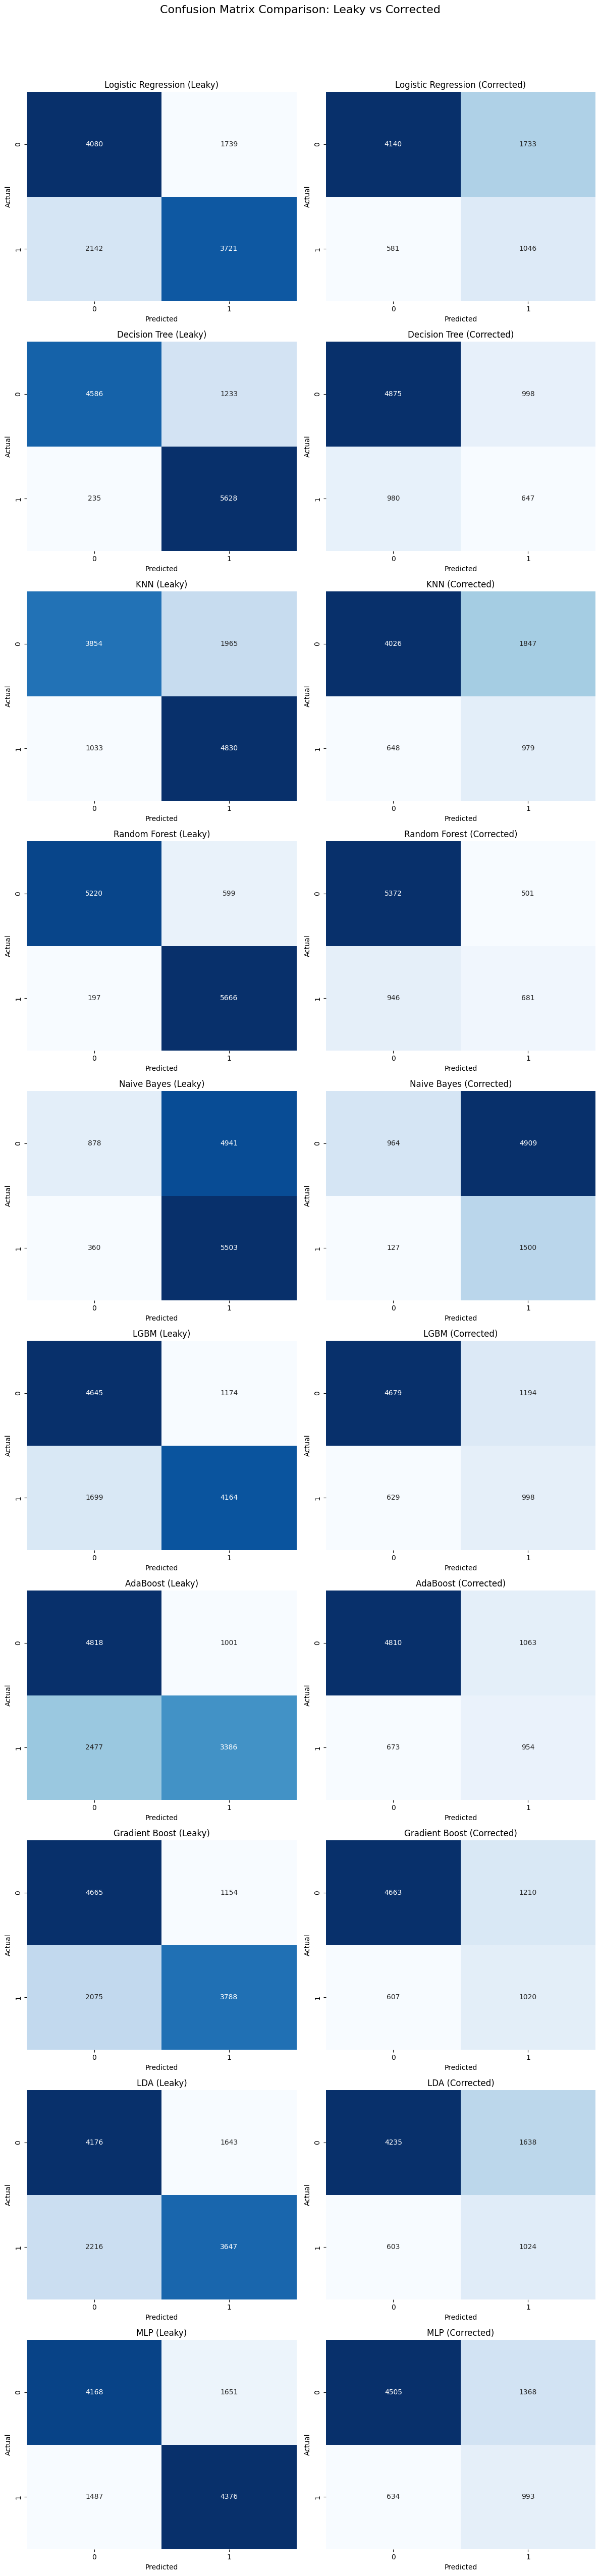

In [13]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

def plot_confusion_matrices(res_df, models_dict):
    algorithms = res_df['Algorithm'].unique()
    n_alg = len(algorithms)

    fig, axes = plt.subplots(n_alg, 2, figsize=(12, 5 * n_alg))
    fig.suptitle('Confusion Matrix Comparison: Leaky vs Corrected', fontsize=16, y=1.02)

    for i, alg in enumerate(algorithms):
        for j, scenario in enumerate(['Leaky', 'Corrected']):
            ax = axes[i, j]

            # Setup data based on scenario
            if scenario == 'Leaky':
                xte, yte = (X_test_leaky_sc, y_test_leaky) if alg in ['Logistic Regression', 'KNN', 'LDA', 'MLP'] else (X_test_leaky, y_test_leaky)
            else:
                xte, yte = (X_test_corr_sc, y_test_corr) if alg in ['Logistic Regression', 'KNN', 'LDA', 'MLP'] else (X_test_corr, y_test_corr)

            # We need to re-fit or use the stored models. Since we didn't store individual scenario models,
            # we quickly re-fit for this visualization to ensure accuracy.
            model = models_dict[alg]
            if scenario == 'Leaky':
                xtr, ytr = (X_train_leaky_sc, y_train_leaky) if alg in ['Logistic Regression', 'KNN', 'LDA', 'MLP'] else (X_train_leaky, y_train_leaky)
            else:
                xtr, ytr = (X_train_corr_sc, y_train_corr) if alg in ['Logistic Regression', 'KNN', 'LDA', 'MLP'] else (X_train_corr, y_train_corr)

            model.fit(xtr, ytr)
            y_pred = model.predict(xte)
            cm = confusion_matrix(yte, y_pred)

            sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False)
            ax.set_title(f'{alg} ({scenario})')
            ax.set_xlabel('Predicted')
            ax.set_ylabel('Actual')

    plt.tight_layout()
    plt.show()

plot_confusion_matrices(res_df, models_dict)

---
# Explainability & Risk Prediction

In [14]:
!pip install -q shap lime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 5.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


## Explainability Input Variables

Change these to control which samples get explained and how many features appear in dependence plots.

In [15]:
SAMPLE_INDICES = [0, 1, 2]
NUM_TOP_FEATURES_DEPENDENCE = 4
FEATURE_NAMES = X.columns.tolist()

## SHAP — Global Explainability (Gradient Boosting)

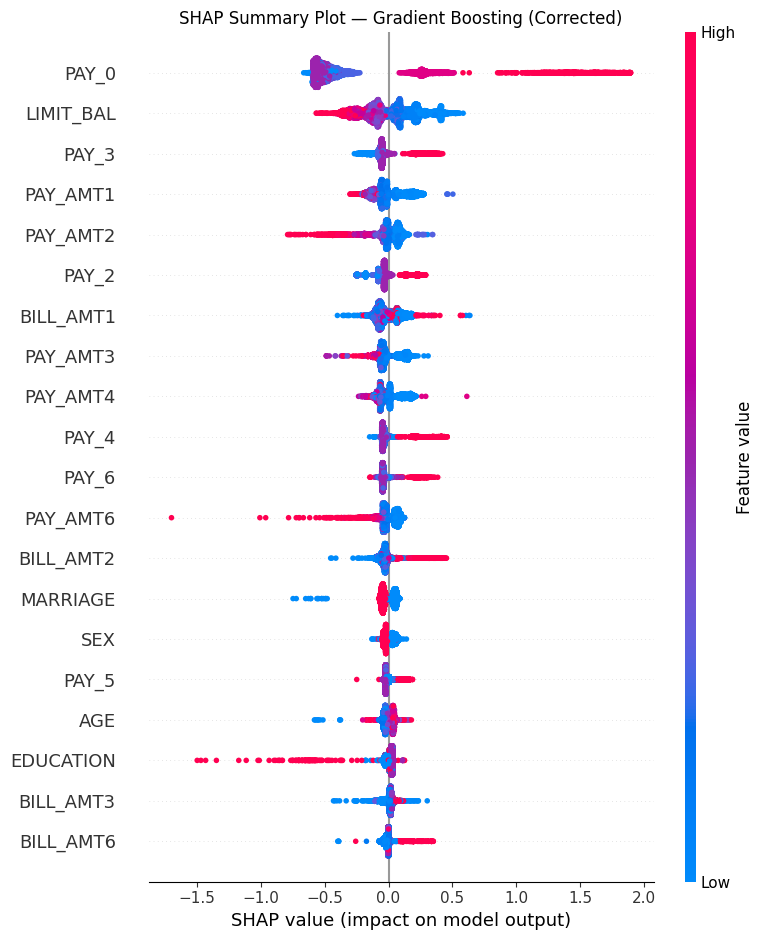

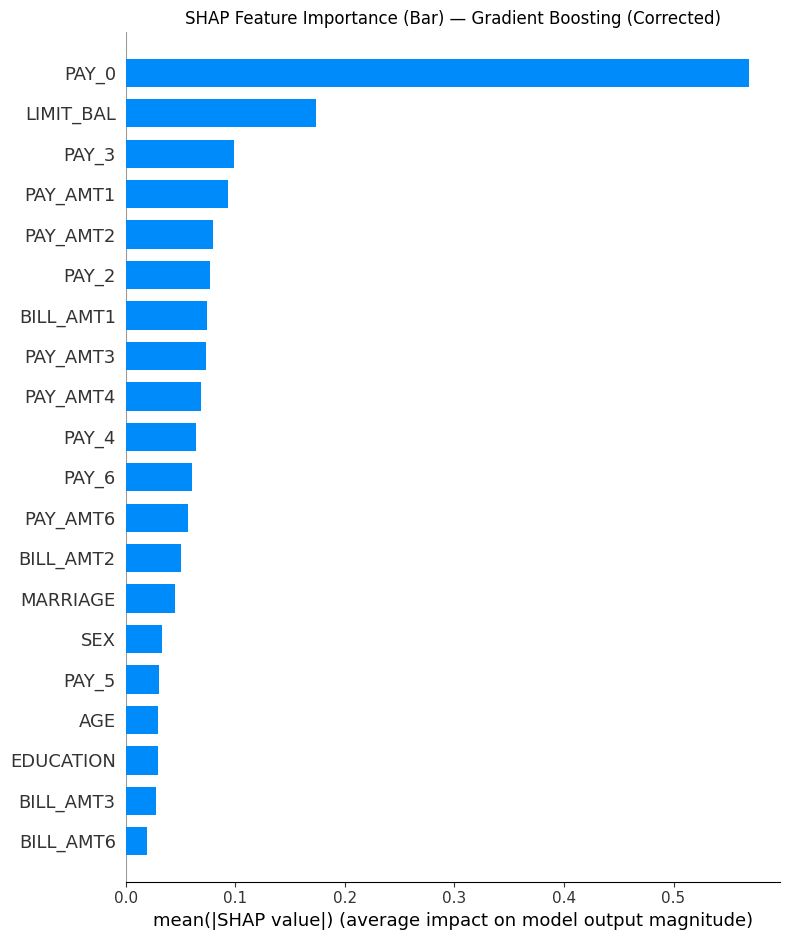

,Feature,Mean_Abs_SHAP
5,PAY_0,0.568725
0,LIMIT_BAL,0.173396
7,PAY_3,0.099116
17,PAY_AMT1,0.093014
18,PAY_AMT2,0.079603
6,PAY_2,0.076673
11,BILL_AMT1,0.074196
19,PAY_AMT3,0.072947
20,PAY_AMT4,0.068415
8,PAY_4,0.064384


In [16]:
import shap

gb_model = models_dict["Gradient Boost"]
gb_explainer = shap.TreeExplainer(gb_model)
gb_shap_values = gb_explainer.shap_values(X_test_corr)

plt.figure(figsize=(12, 8))
shap.summary_plot(gb_shap_values, X_test_corr, feature_names=FEATURE_NAMES, show=False)
plt.title("SHAP Summary Plot — Gradient Boosting (Corrected)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
shap.summary_plot(gb_shap_values, X_test_corr, feature_names=FEATURE_NAMES, plot_type="bar", show=False)
plt.title("SHAP Feature Importance (Bar) — Gradient Boosting (Corrected)")
plt.tight_layout()
plt.show()

gb_shap_importance = pd.DataFrame({
    "Feature": FEATURE_NAMES,
    "Mean_Abs_SHAP": np.abs(gb_shap_values).mean(axis=0),
}).sort_values("Mean_Abs_SHAP", ascending=False)
display(gb_shap_importance)

## SHAP — Local Explainability / Waterfall (Gradient Boosting)

Shows exactly which features pushed each individual prediction toward default or non-default.

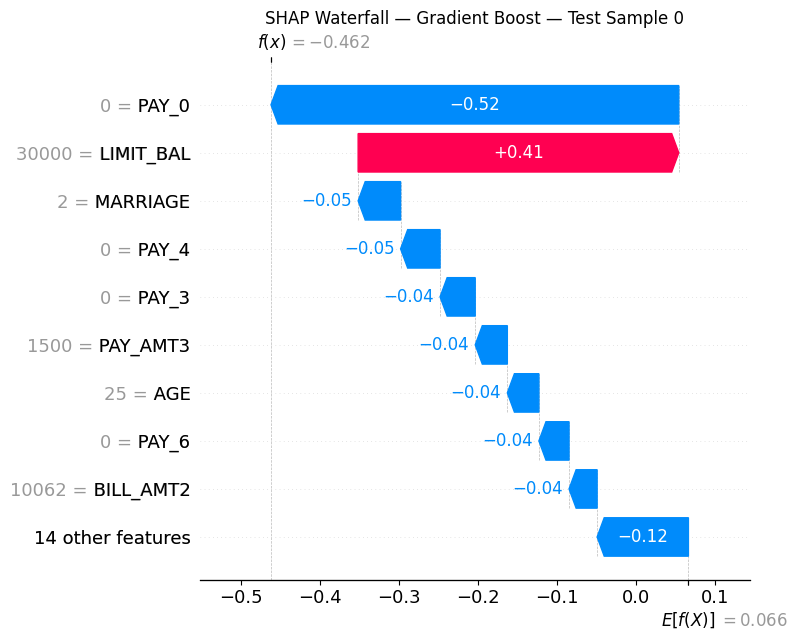

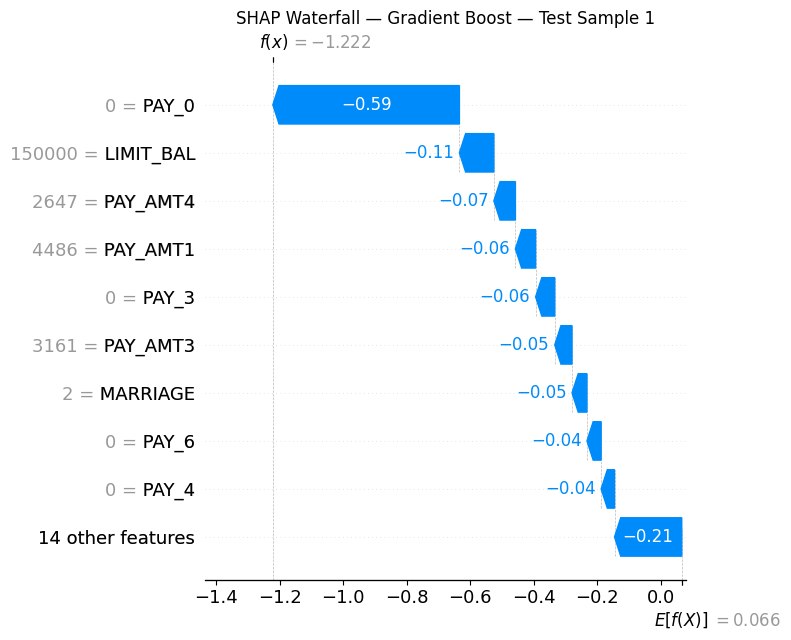

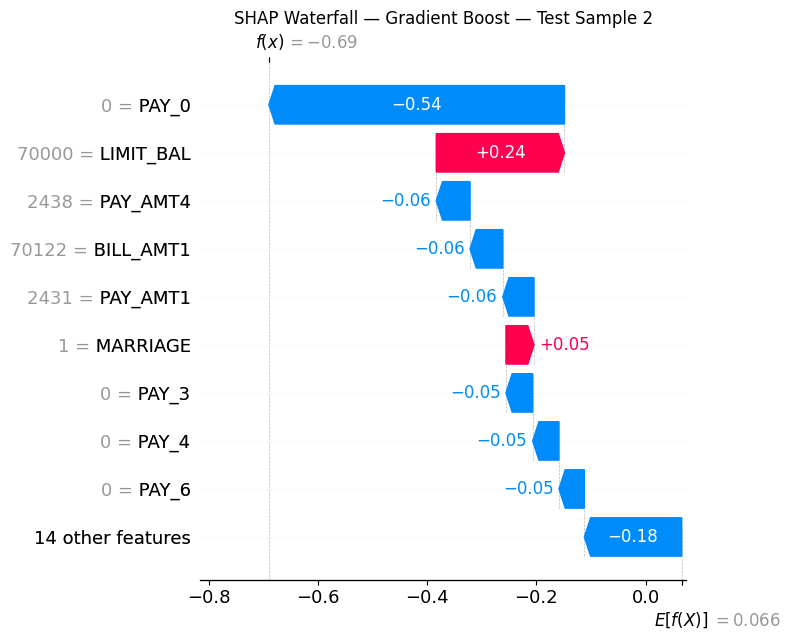

In [17]:
for sample_idx in SAMPLE_INDICES:
    shap_explanation = shap.Explanation(
        values=gb_shap_values[sample_idx],
        base_values=gb_explainer.expected_value,
        data=X_test_corr.iloc[sample_idx].values,
        feature_names=FEATURE_NAMES,
    )

    plt.figure(figsize=(10, 6))
    shap.waterfall_plot(shap_explanation, show=False)
    plt.title(f"SHAP Waterfall — Gradient Boost — Test Sample {sample_idx}")
    plt.tight_layout()
    plt.show()

## SHAP — Dependence Plots (Gradient Boosting)

Shows how a single feature's value relates to its SHAP contribution, colored by an interaction feature.

<Figure size 800x500 with 0 Axes>

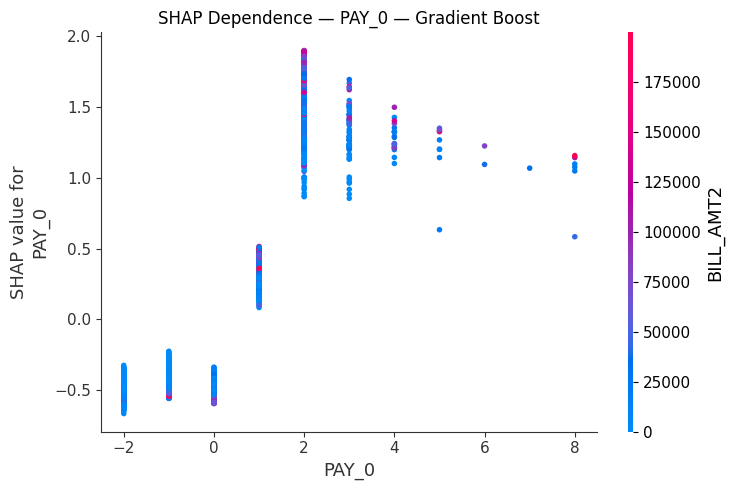

<Figure size 800x500 with 0 Axes>

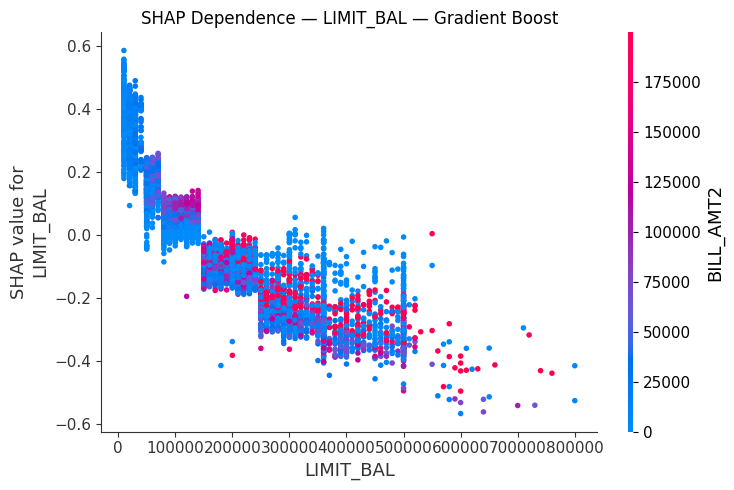

<Figure size 800x500 with 0 Axes>

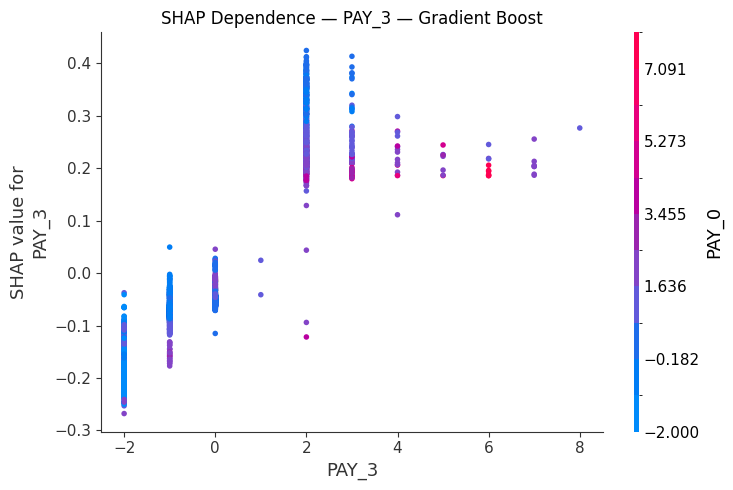

<Figure size 800x500 with 0 Axes>

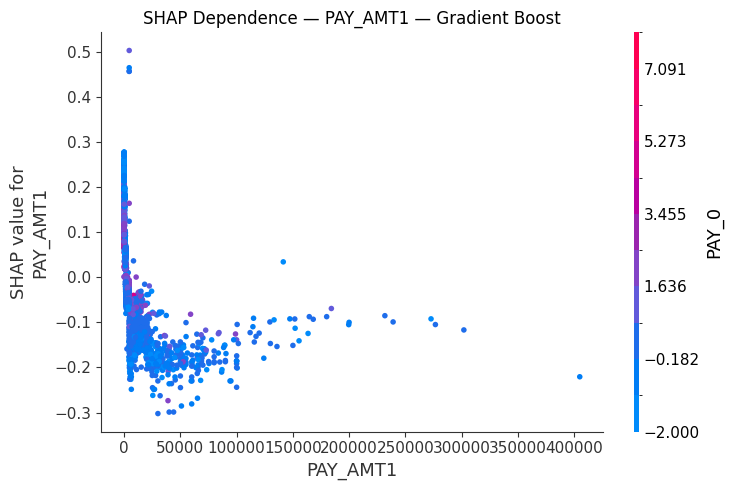

In [18]:
top_features = gb_shap_importance["Feature"].head(NUM_TOP_FEATURES_DEPENDENCE).tolist()

for feature in top_features:
    plt.figure(figsize=(8, 5))
    shap.dependence_plot(feature, gb_shap_values, X_test_corr, feature_names=FEATURE_NAMES, show=False)
    plt.title(f"SHAP Dependence — {feature} — Gradient Boost")
    plt.tight_layout()
    plt.show()

## SHAP — Global Explainability (Random Forest)

Fitting the optimal Random Forest model...
Training complete! Starting SHAP and LIME Analyses...

Processing SHAP Values...


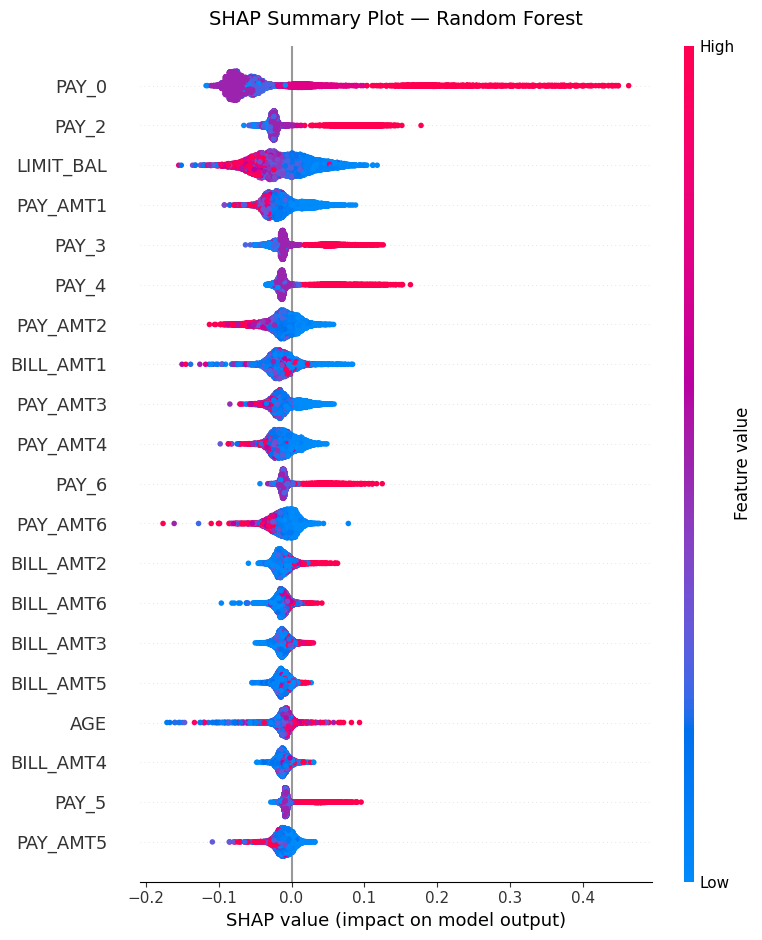

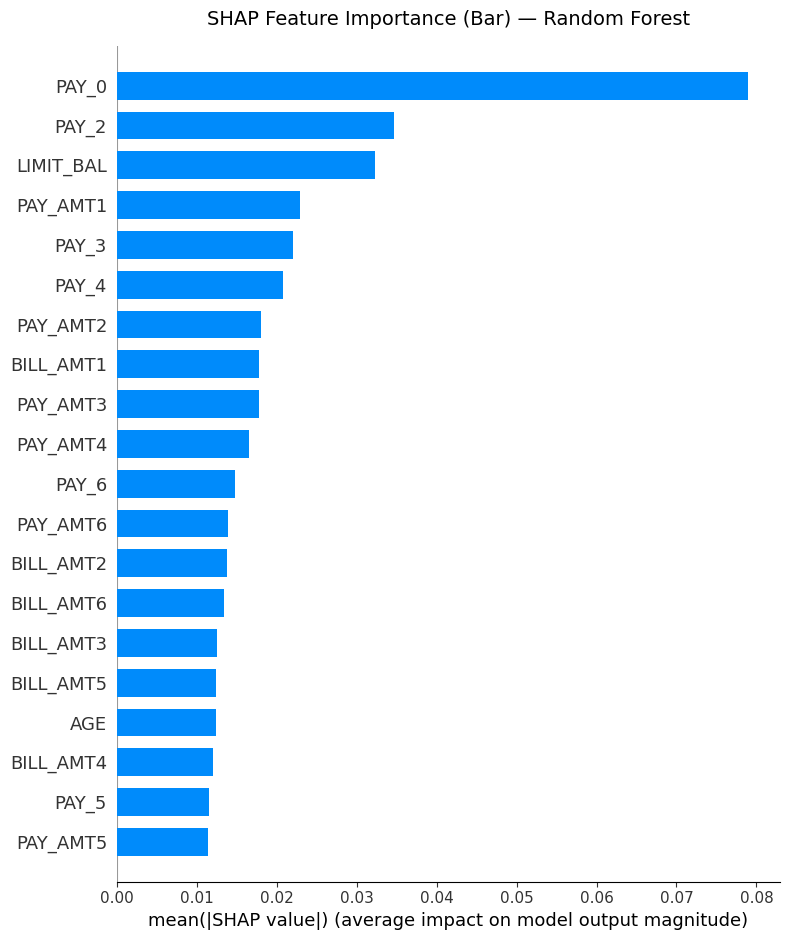

--- Global Feature Importance (SHAP) ---


,Feature,Mean_Abs_SHAP
5,PAY_0,0.078996
6,PAY_2,0.034721
0,LIMIT_BAL,0.032229
17,PAY_AMT1,0.022938
7,PAY_3,0.022040
8,PAY_4,0.020804
18,PAY_AMT2,0.017989
11,BILL_AMT1,0.017821
19,PAY_AMT3,0.017748
20,PAY_AMT4,0.016592




Initializing LIME Explainer...


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


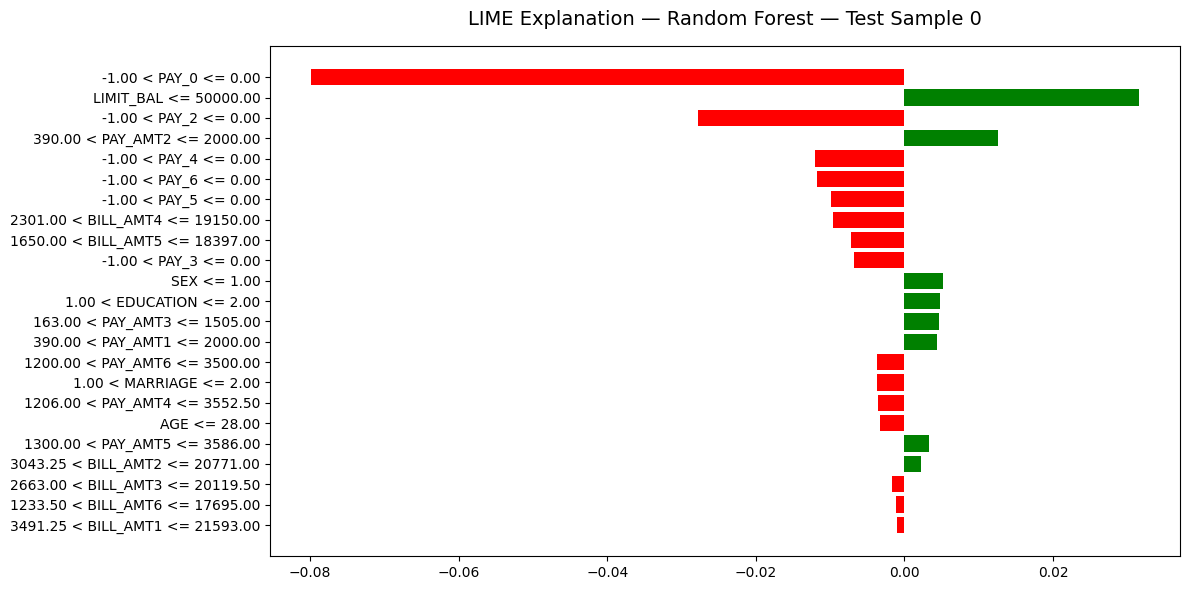

--- Top Feature Contributions for Sample 0 ---


,Feature Rule,Weight
0,-1.00 < PAY_0 <= 0.00,-0.079813
1,LIMIT_BAL <= 50000.00,0.031524
2,-1.00 < PAY_2 <= 0.00,-0.027827
3,390.00 < PAY_AMT2 <= 2000.00,0.012573
4,-1.00 < PAY_4 <= 0.00,-0.011971
5,-1.00 < PAY_6 <= 0.00,-0.011793
6,-1.00 < PAY_5 <= 0.00,-0.009817
7,2301.00 < BILL_AMT4 <= 19150.00,-0.009667
8,1650.00 < BILL_AMT5 <= 18397.00,-0.007146
9,-1.00 < PAY_3 <= 0.00,-0.006770


--------------------------------------------------------------------------------


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


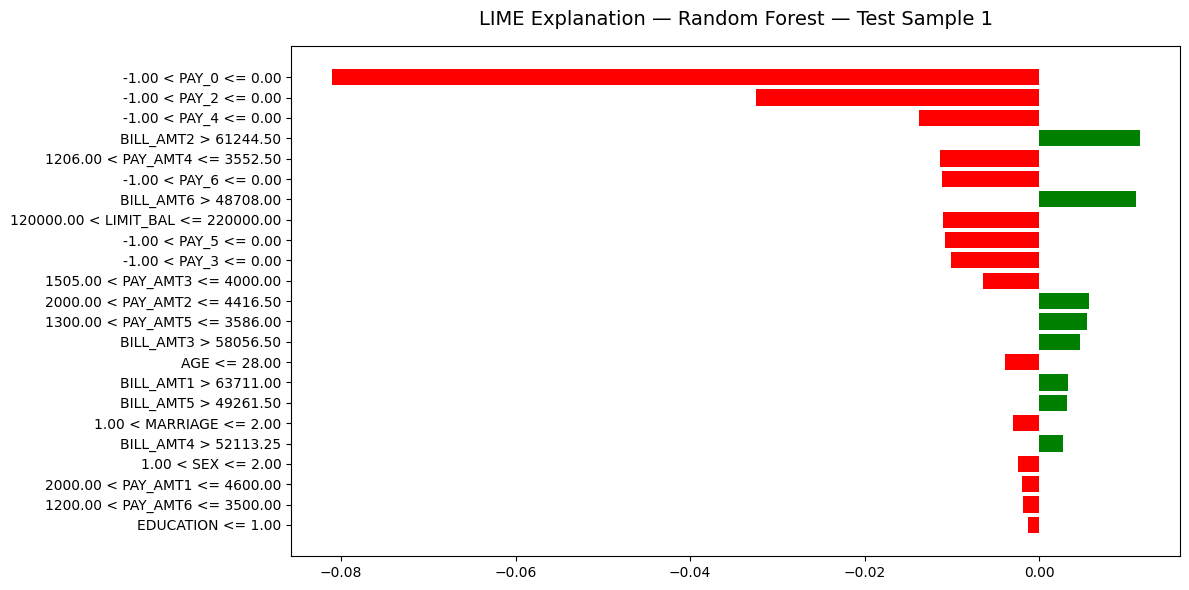

--- Top Feature Contributions for Sample 1 ---


,Feature Rule,Weight
0,-1.00 < PAY_0 <= 0.00,-0.081094
1,-1.00 < PAY_2 <= 0.00,-0.032494
2,-1.00 < PAY_4 <= 0.00,-0.013741
3,BILL_AMT2 > 61244.50,0.011512
4,1206.00 < PAY_AMT4 <= 3552.50,-0.011374
5,-1.00 < PAY_6 <= 0.00,-0.011158
6,BILL_AMT6 > 48708.00,0.011074
7,120000.00 < LIMIT_BAL <= 220000.00,-0.011039
8,-1.00 < PAY_5 <= 0.00,-0.010832
9,-1.00 < PAY_3 <= 0.00,-0.010087


--------------------------------------------------------------------------------


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


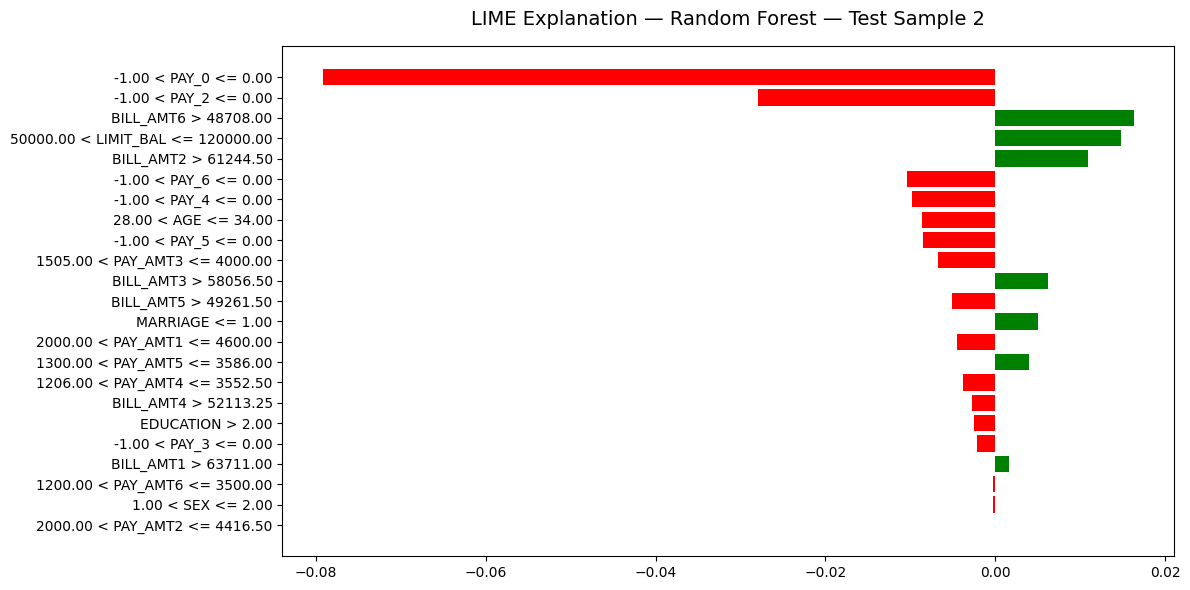

--- Top Feature Contributions for Sample 2 ---


,Feature Rule,Weight
0,-1.00 < PAY_0 <= 0.00,-0.079193
1,-1.00 < PAY_2 <= 0.00,-0.027962
2,BILL_AMT6 > 48708.00,0.016292
3,50000.00 < LIMIT_BAL <= 120000.00,0.014768
4,BILL_AMT2 > 61244.50,0.010944
5,-1.00 < PAY_6 <= 0.00,-0.010448
6,-1.00 < PAY_4 <= 0.00,-0.009750
7,28.00 < AGE <= 34.00,-0.008621
8,-1.00 < PAY_5 <= 0.00,-0.008564
9,1505.00 < PAY_AMT3 <= 4000.00,-0.006779


--------------------------------------------------------------------------------


In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
import lime
import lime.lime_tabular
from sklearn.ensemble import RandomForestClassifier

# =====================================================================
# 1. TRAIN OPTIMAL RANDOM FOREST MODEL
# =====================================================================
print("Fitting the optimal Random Forest model...")
rf_model = RandomForestClassifier(
    criterion='entropy',
    max_depth=None,
    min_samples_split=2,
    n_estimators=200,
    random_state=42
)
rf_model.fit(X_train_corr, y_train_corr)
print("Training complete! Starting SHAP and LIME Analyses...\n")


# =====================================================================
# 2. SHAP GLOBAL ANALYSIS
# =====================================================================
print("Processing SHAP Values...")
rf_explainer = shap.TreeExplainer(rf_model)
rf_shap_values_raw = rf_explainer.shap_values(X_test_corr)

# Handle output discrepancies between different SHAP/scikit-learn packaging versions
rf_shap_values = rf_shap_values_raw[1] if isinstance(rf_shap_values_raw, list) else rf_shap_values_raw

if hasattr(rf_shap_values, "values"):
    shap_matrix = rf_shap_values.values
else:
    shap_matrix = rf_shap_values

if len(shap_matrix.shape) == 3:
    shap_matrix = shap_matrix[:, :, 1]

# Plot 2A: SHAP Summary Dot Plot
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_matrix, X_test_corr, feature_names=FEATURE_NAMES, show=False)
plt.title("SHAP Summary Plot — Random Forest", fontsize=14, pad=15)
plt.tight_layout()
plt.show()

# Plot 2B: SHAP Feature Importance Bar Plot
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_matrix, X_test_corr, feature_names=FEATURE_NAMES, plot_type="bar", show=False)
plt.title("SHAP Feature Importance (Bar) — Random Forest", fontsize=14, pad=15)
plt.tight_layout()
plt.show()

# Table 2C: Global Importance DataFrame
rf_shap_importance = pd.DataFrame({
    "Feature": FEATURE_NAMES,
    "Mean_Abs_SHAP": np.abs(shap_matrix).mean(axis=0),
}).sort_values("Mean_Abs_SHAP", ascending=False)
print("--- Global Feature Importance (SHAP) ---")
display(rf_shap_importance)
print("\n" + "="*80 + "\n")


# =====================================================================
# 3. LIME LOCAL ANALYSIS (DEBUGGED)
# =====================================================================
print("Initializing LIME Explainer...")
lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train_corr.values,
    feature_names=FEATURE_NAMES,
    class_names=["No Default", "Default"],
    mode="classification",
)

# Iterating over your target observation indices
for sample_idx in SAMPLE_INDICES:
    explanation = lime_explainer.explain_instance(
        X_test_corr.iloc[sample_idx].values,
        rf_model.predict_proba,
        num_features=len(FEATURE_NAMES)  # <-- FIXED: Removed the duplicate, invalid 'feature_names' parameter
    )

    # Plot 3A: Sample Plot Output
    fig = explanation.as_pyplot_figure()
    fig.set_size_inches(12, 6)
    plt.title(f"LIME Explanation — Random Forest — Test Sample {sample_idx}", fontsize=14, pad=15)
    plt.tight_layout()
    plt.show()

    # Table 3B: Decision Rule Matrix
    lime_df = pd.DataFrame(explanation.as_list(), columns=["Feature Rule", "Weight"])
    print(f"--- Top Feature Contributions for Sample {sample_idx} ---")
    display(lime_df)
    print("-" * 80)

## LIME — Local Explainability (Gradient Boosting)

LIME builds a simple local model around each prediction to explain which features matter most for that specific case.

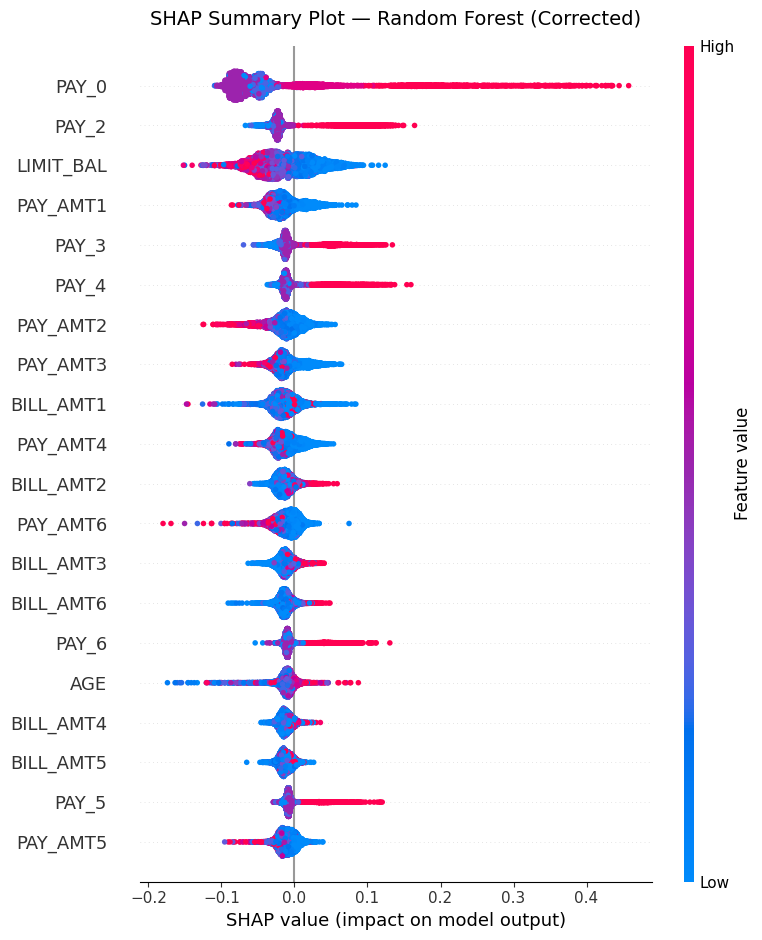

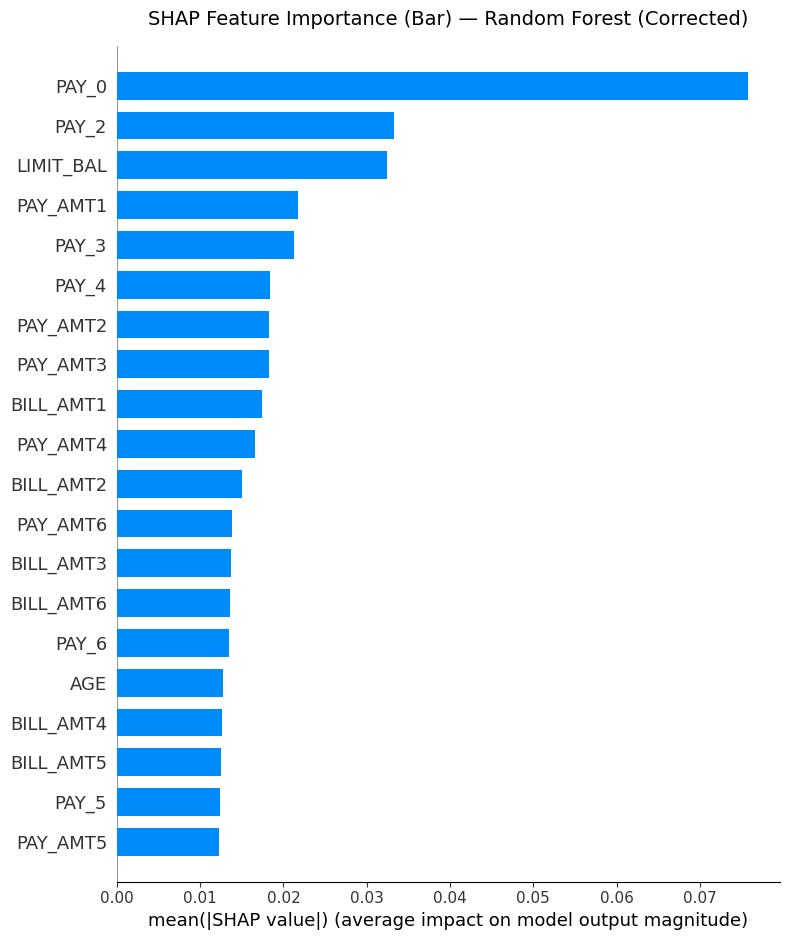

,Feature,Mean_Abs_SHAP
5,PAY_0,0.075834
6,PAY_2,0.033244
0,LIMIT_BAL,0.032428
17,PAY_AMT1,0.021747
7,PAY_3,0.021222
8,PAY_4,0.018435
18,PAY_AMT2,0.018298
19,PAY_AMT3,0.018276
11,BILL_AMT1,0.017434
20,PAY_AMT4,0.016614


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but GradientBoostingClassifier was fitted with feature names
  warnings.warn(


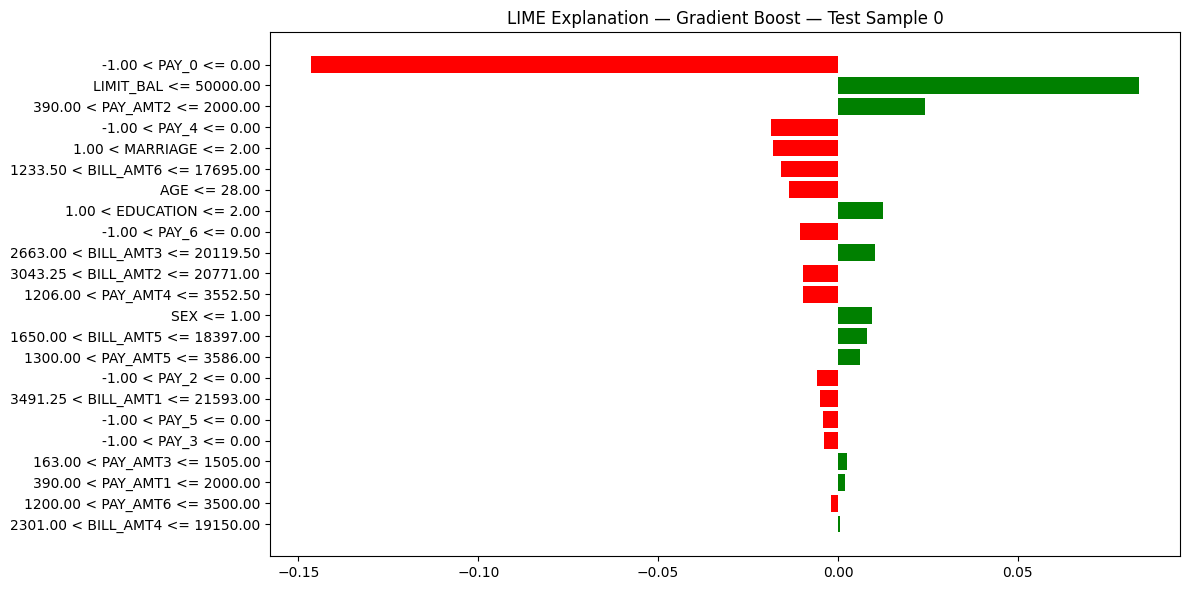

,Feature Rule,Weight
0,-1.00 < PAY_0 <= 0.00,-0.146369
1,LIMIT_BAL <= 50000.00,0.083563
2,390.00 < PAY_AMT2 <= 2000.00,0.024177
3,-1.00 < PAY_4 <= 0.00,-0.018629
4,1.00 < MARRIAGE <= 2.00,-0.018017
5,1233.50 < BILL_AMT6 <= 17695.00,-0.015874
6,AGE <= 28.00,-0.013495
7,1.00 < EDUCATION <= 2.00,0.012614
8,-1.00 < PAY_6 <= 0.00,-0.010573
9,2663.00 < BILL_AMT3 <= 20119.50,0.010184


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but GradientBoostingClassifier was fitted with feature names
  warnings.warn(


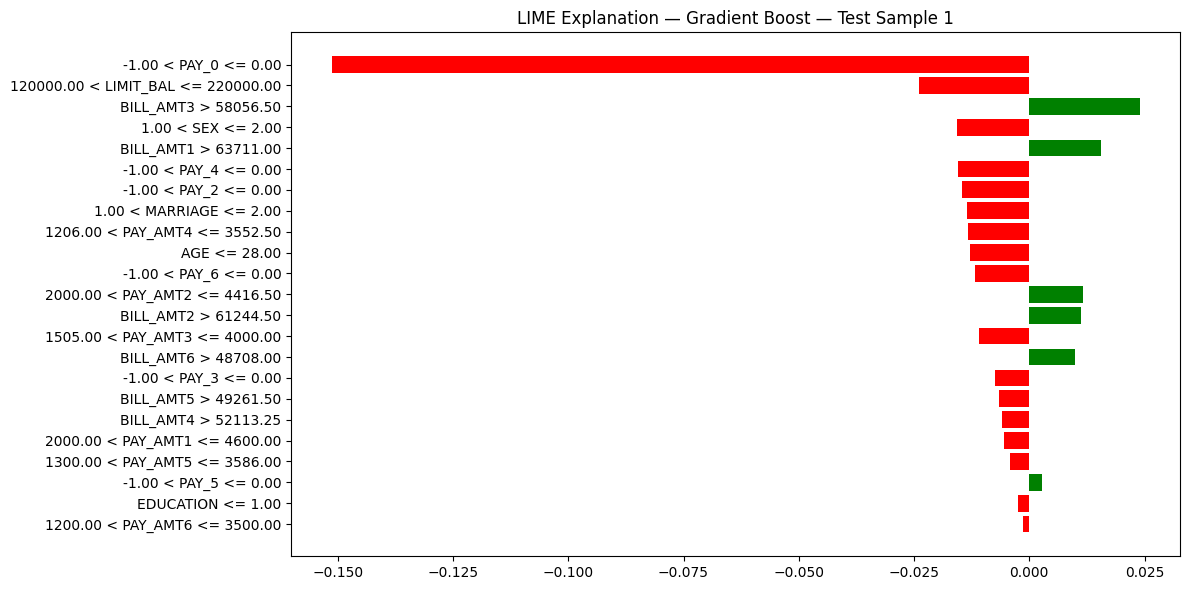

,Feature Rule,Weight
0,-1.00 < PAY_0 <= 0.00,-0.151344
1,120000.00 < LIMIT_BAL <= 220000.00,-0.023969
2,BILL_AMT3 > 58056.50,0.023920
3,1.00 < SEX <= 2.00,-0.015690
4,BILL_AMT1 > 63711.00,0.015528
5,-1.00 < PAY_4 <= 0.00,-0.015524
6,-1.00 < PAY_2 <= 0.00,-0.014699
7,1.00 < MARRIAGE <= 2.00,-0.013424
8,1206.00 < PAY_AMT4 <= 3552.50,-0.013220
9,AGE <= 28.00,-0.012967


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but GradientBoostingClassifier was fitted with feature names
  warnings.warn(


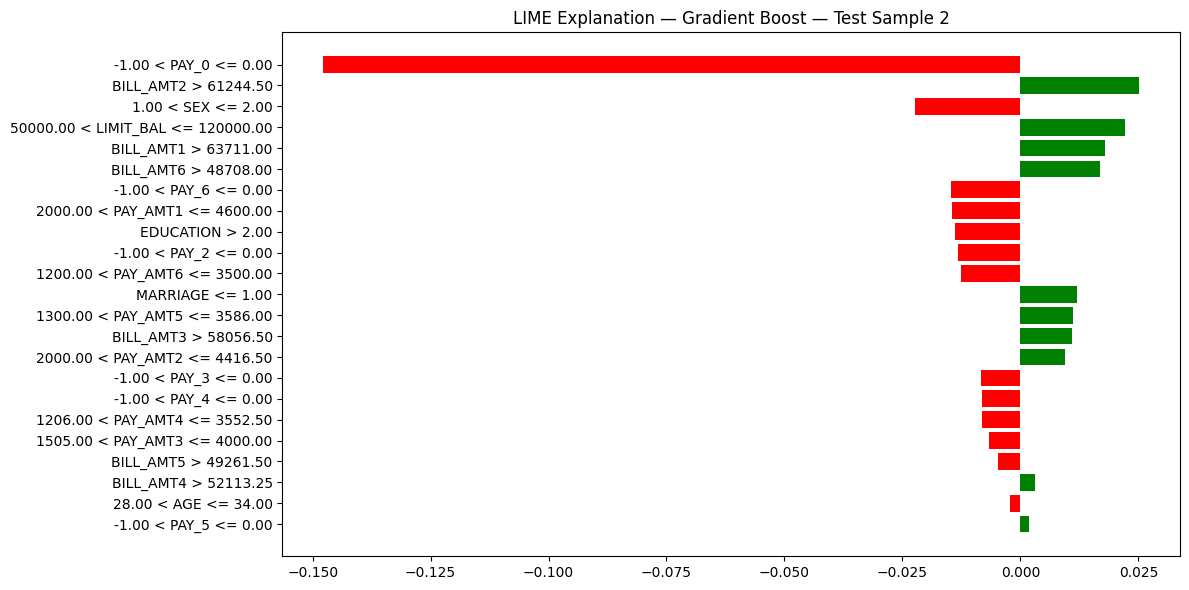

,Feature Rule,Weight
0,-1.00 < PAY_0 <= 0.00,-0.147766
1,BILL_AMT2 > 61244.50,0.025179
2,1.00 < SEX <= 2.00,-0.022426
3,50000.00 < LIMIT_BAL <= 120000.00,0.022271
4,BILL_AMT1 > 63711.00,0.017981
5,BILL_AMT6 > 48708.00,0.016782
6,-1.00 < PAY_6 <= 0.00,-0.014662
7,2000.00 < PAY_AMT1 <= 4600.00,-0.014393
8,EDUCATION > 2.00,-0.013960
9,-1.00 < PAY_2 <= 0.00,-0.013327


In [20]:
import lime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap

# 1. Extract model and compute SHAP values
rf_model = models_dict["Random Forest"]
rf_explainer = shap.TreeExplainer(rf_model)
rf_shap_values_raw = rf_explainer.shap_values(X_test_corr)

# Handle potential list wrapper from older/different SHAP version behaviors
rf_shap_values = rf_shap_values_raw[1] if isinstance(rf_shap_values_raw, list) else rf_shap_values_raw

# 2. Extract raw numpy array matrix safely to handle multi-dimensional wrappers
if hasattr(rf_shap_values, "values"):
    shap_matrix = rf_shap_values.values
else:
    shap_matrix = rf_shap_values

# If a redundant 3rd dimension exists (samples, features, classes), extract class 1
if len(shap_matrix.shape) == 3:
    shap_matrix = shap_matrix[:, :, 1]

# 3. Generate SHAP Summary Dot Plot
plt.figure(figsize=(12, 8))
# Pass the underlying data array to prevent structural mismatch
shap.summary_plot(shap_matrix, X_test_corr, feature_names=FEATURE_NAMES, show=False)
plt.title("SHAP Summary Plot — Random Forest (Corrected)", fontsize=14, pad=15)
plt.tight_layout()
plt.show()

# 4. Generate SHAP Feature Importance Bar Plot
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_matrix, X_test_corr, feature_names=FEATURE_NAMES, plot_type="bar", show=False)
plt.title("SHAP Feature Importance (Bar) — Random Forest (Corrected)", fontsize=14, pad=15)
plt.tight_layout()
plt.show()

# 5. Create and Display the Importance DataFrame
# shape_matrix is guaranteed to be a 2D matrix, so .mean(axis=0) output will match FEATURE_NAMES perfectly
rf_shap_importance = pd.DataFrame({
    "Feature": FEATURE_NAMES,
    "Mean_Abs_SHAP": np.abs(shap_matrix).mean(axis=0),
}).sort_values("Mean_Abs_SHAP", ascending=False)

display(rf_shap_importance)
import lime.lime_tabular

lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train_corr.values,
    feature_names=FEATURE_NAMES,
    class_names=["No Default", "Default"],
    mode="classification",
)

for sample_idx in SAMPLE_INDICES:
    explanation = lime_explainer.explain_instance(
        X_test_corr.iloc[sample_idx].values,
        models_dict["Gradient Boost"].predict_proba,
        num_features=len(FEATURE_NAMES),
    )

    fig = explanation.as_pyplot_figure()
    fig.set_size_inches(12, 6)
    plt.title(f"LIME Explanation — Gradient Boost — Test Sample {sample_idx}")
    plt.tight_layout()
    plt.show()

    lime_df = pd.DataFrame(explanation.as_list(), columns=["Feature Rule", "Weight"])
    display(lime_df)

## LIME — Local Explainability (Random Forest)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


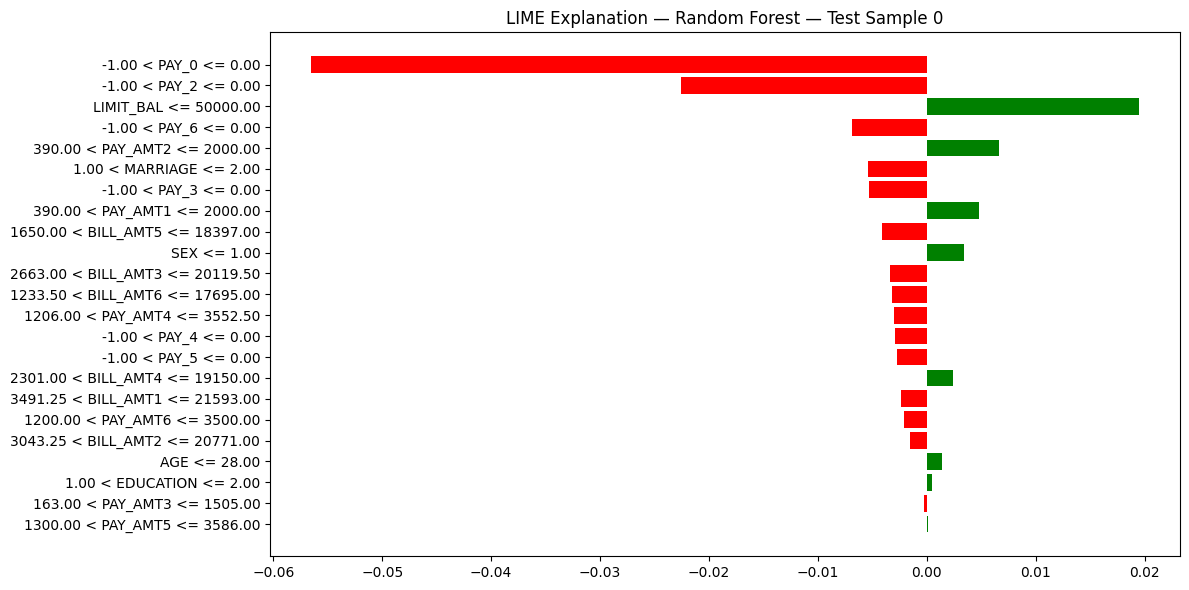

,Feature Rule,Weight
0,-1.00 < PAY_0 <= 0.00,-0.056493
1,-1.00 < PAY_2 <= 0.00,-0.022595
2,LIMIT_BAL <= 50000.00,0.019452
3,-1.00 < PAY_6 <= 0.00,-0.006842
4,390.00 < PAY_AMT2 <= 2000.00,0.006675
5,1.00 < MARRIAGE <= 2.00,-0.005406
6,-1.00 < PAY_3 <= 0.00,-0.005340
7,390.00 < PAY_AMT1 <= 2000.00,0.004805
8,1650.00 < BILL_AMT5 <= 18397.00,-0.004144
9,SEX <= 1.00,0.003406


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


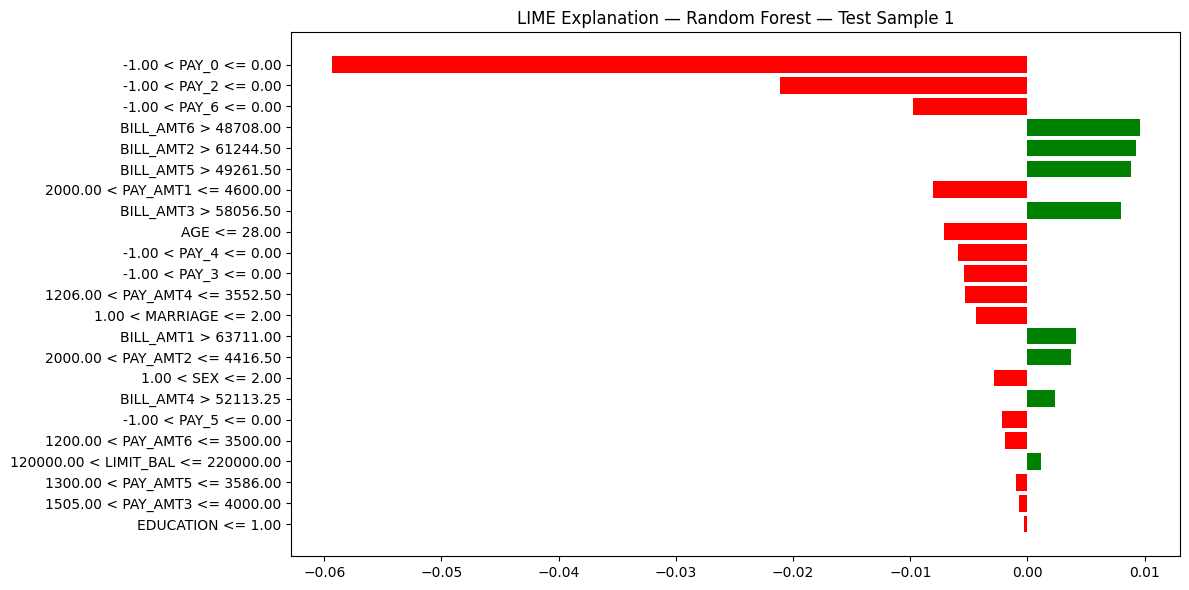

,Feature Rule,Weight
0,-1.00 < PAY_0 <= 0.00,-0.059380
1,-1.00 < PAY_2 <= 0.00,-0.021104
2,-1.00 < PAY_6 <= 0.00,-0.009765
3,BILL_AMT6 > 48708.00,0.009567
4,BILL_AMT2 > 61244.50,0.009218
5,BILL_AMT5 > 49261.50,0.008802
6,2000.00 < PAY_AMT1 <= 4600.00,-0.008033
7,BILL_AMT3 > 58056.50,0.008014
8,AGE <= 28.00,-0.007131
9,-1.00 < PAY_4 <= 0.00,-0.005916


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


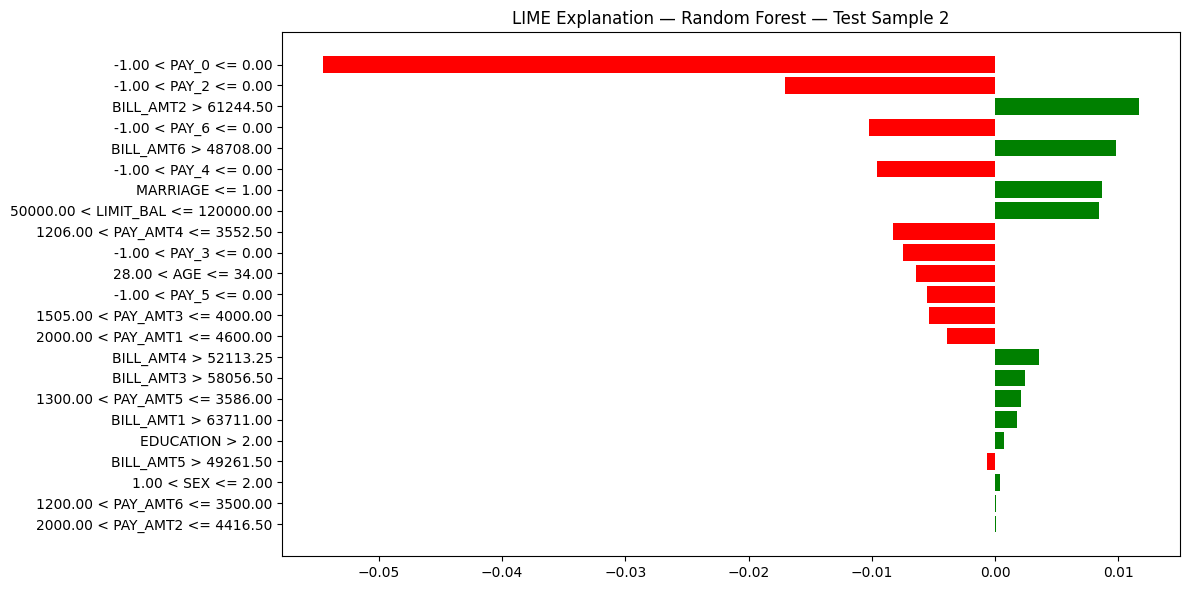

,Feature Rule,Weight
0,-1.00 < PAY_0 <= 0.00,-0.054507
1,-1.00 < PAY_2 <= 0.00,-0.017063
2,BILL_AMT2 > 61244.50,0.011681
3,-1.00 < PAY_6 <= 0.00,-0.010222
4,BILL_AMT6 > 48708.00,0.009776
5,-1.00 < PAY_4 <= 0.00,-0.009604
6,MARRIAGE <= 1.00,0.008650
7,50000.00 < LIMIT_BAL <= 120000.00,0.008402
8,1206.00 < PAY_AMT4 <= 3552.50,-0.008317
9,-1.00 < PAY_3 <= 0.00,-0.007479


In [21]:
for sample_idx in SAMPLE_INDICES:
    explanation = lime_explainer.explain_instance(
        X_test_corr.iloc[sample_idx].values,
        models_dict["Random Forest"].predict_proba,
        num_features=len(FEATURE_NAMES),
    )

    fig = explanation.as_pyplot_figure()
    fig.set_size_inches(12, 6)
    plt.title(f"LIME Explanation — Random Forest — Test Sample {sample_idx}")
    plt.tight_layout()
    plt.show()

    lime_df = pd.DataFrame(explanation.as_list(), columns=["Feature Rule", "Weight"])
    display(lime_df)

In [22]:
!pip install xgboost lightgbm catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 5.6 MB/s eta 0:00:00


In [23]:
import os
import json
import joblib
import numpy as np
import pandas as pd

# Model Class Imports
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier, ExtraTreesClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

# 1. Base Configuration Directory Setup
base_models_dir = "models"
os.makedirs(base_models_dir, exist_ok=True)

# 2. Master Blueprint of all 15 Models with default/stable baselines
models_blueprint = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(criterion='entropy', random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Random Forest": RandomForestClassifier(n_estimators=200, criterion='entropy', random_state=42),
    "Naive Bayes": GaussianNB(),
    "LGBM": LGBMClassifier(n_estimators=200, random_state=42, verbose=-1),
    "AdaBoost": AdaBoostClassifier(n_estimators=200, random_state=42),
    "Gradient Boost": GradientBoostingClassifier(n_estimators=200, random_state=42),
    "LDA": LinearDiscriminantAnalysis(solver='lsqr', shrinkage='auto'), # Safe solver combination
    "MLP": MLPClassifier(max_iter=500, random_state=42),
    "SVM": SVC(probability=True, random_state=42), # probability=True keeps .predict_proba functional for LIME
    "XGBoost": XGBClassifier(n_estimators=200, random_state=42, eval_metric='logloss'),
    "CatBoost": CatBoostClassifier(iterations=200, random_state=42, verbose=0),
    "Extra Trees": ExtraTreesClassifier(n_estimators=200, random_state=42),
    "SGD Classifier": SGDClassifier(loss='log_loss', max_iter=1000, random_state=42) # log_loss yields probabilities
}

print(f"Starting sequential training and structured export for all {len(models_blueprint)} models...\n")

# 3. Execution, Structure Generation, and Serialization Loop
for idx, (name, model_instance) in enumerate(models_blueprint.items()):
    print(f"[{idx+1}/15] Processing: {name}...", end=" ")

    # Standardizing lowercase folder naming conversions (e.g., "Random Forest" -> "random_forest")
    folder_name = name.lower().replace(" ", "_")
    model_folder = os.path.join(base_models_dir, folder_name)
    config_folder = os.path.join(model_folder, "config")
    weights_folder = os.path.join(model_folder, "weights")

    # Establish subfolder skeleton structures
    os.makedirs(config_folder, exist_ok=True)
    os.makedirs(weights_folder, exist_ok=True)

    try:
        # Fit model using active notebook arrays
        model_instance.fit(X_train_corr, y_train_corr)

        # Pull parameters dynamically out of the active classifier object instance
        active_params = model_instance.get_params()

        # Sanitize parameters (convert complex object types/classes to text strings so JSON can save it)
        sanitized_params = {
            k: (str(v) if not isinstance(v, (int, float, str, bool, list, dict, type(None))) else v)
            for k, v in active_params.items()
        }

        # Save structural tracking configurations
        config_path = os.path.join(config_folder, "hyperparameters.json")
        with open(config_path, "w") as json_file:
            json.dump(sanitized_params, json_file, indent=4)

        # Serialize model weights binary
        model_weights_path = os.path.join(weights_folder, "model.joblib")
        joblib.dump(model_instance, model_weights_path)

        print("Success! -> Exported to disk.")

    except Exception as e:
        print(f"FAILED execution step. Error details: {e}")

print("\nAll 15 target models have been generated, structured, and saved successfully!")

Starting sequential training and structured export for all 15 models...

[1/15] Processing: Logistic Regression... 

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Success! -> Exported to disk.
[2/15] Processing: Decision Tree... Success! -> Exported to disk.
[3/15] Processing: KNN... Success! -> Exported to disk.
[4/15] Processing: Random Forest... Success! -> Exported to disk.
[5/15] Processing: Naive Bayes... Success! -> Exported to disk.
[6/15] Processing: LGBM... Success! -> Exported to disk.
[7/15] Processing: AdaBoost... Success! -> Exported to disk.
[8/15] Processing: Gradient Boost... Success! -> Exported to disk.
[9/15] Processing: LDA... Success! -> Exported to disk.
[10/15] Processing: MLP... Success! -> Exported to disk.
[11/15] Processing: SVM... Success! -> Exported to disk.
[12/15] Processing: XGBoost... Success! -> Exported to disk.
[13/15] Processing: CatBoost... Success! -> Exported to disk.
[14/15] Processing: Extra Trees... Success! -> Exported to disk.
[15/15] Processing: SGD Classifier... Success! -> Exported to disk.

All 15 target models have been generated, structured, and saved successfully!


## Permutation Importance (Model-Agnostic)

Measures how much each feature matters by shuffling it and observing the F1 score drop. Unlike built-in importance, this works for any model.

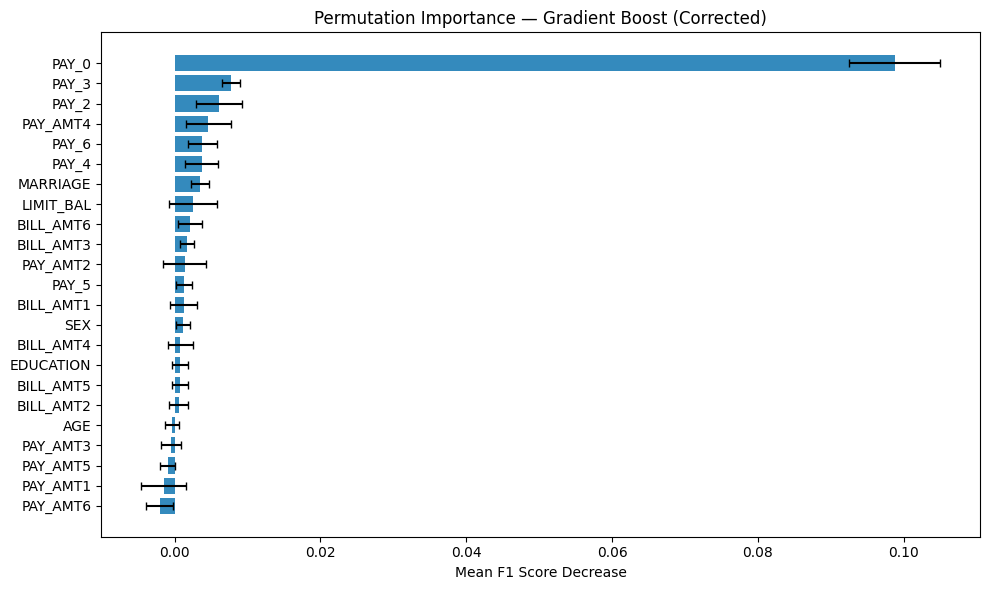

,Feature,Importance_Mean,Importance_Std
5,PAY_0,0.098754,0.006229
7,PAY_3,0.007776,0.001251
6,PAY_2,0.006139,0.003159
20,PAY_AMT4,0.004613,0.003118
10,PAY_6,0.003786,0.002009
8,PAY_4,0.003695,0.002214
3,MARRIAGE,0.003481,0.001183
0,LIMIT_BAL,0.002481,0.003323
16,BILL_AMT6,0.002099,0.001585
13,BILL_AMT3,0.001676,0.000927


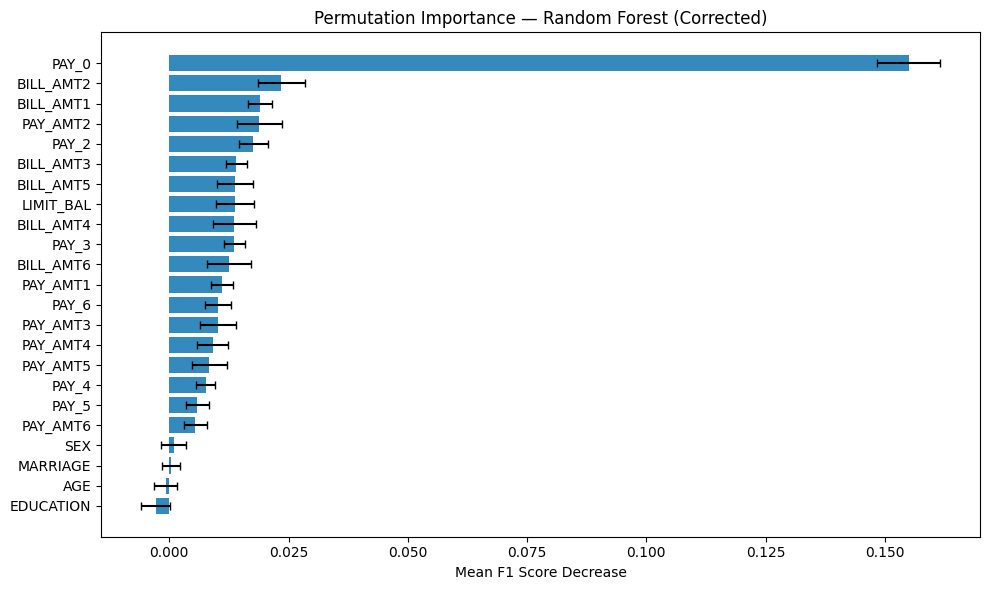

,Feature,Importance_Mean,Importance_Std
5,PAY_0,0.154980,0.006590
12,BILL_AMT2,0.023466,0.004910
11,BILL_AMT1,0.018997,0.002585
18,PAY_AMT2,0.018898,0.004683
6,PAY_2,0.017618,0.002988
13,BILL_AMT3,0.014005,0.002209
15,BILL_AMT5,0.013823,0.003802
0,LIMIT_BAL,0.013807,0.003908
14,BILL_AMT4,0.013615,0.004488
7,PAY_3,0.013590,0.002181


In [24]:
from sklearn.inspection import permutation_importance

for model_name in ["Gradient Boost", "Random Forest"]:
    model = models_dict[model_name]
    perm_result = permutation_importance(
        model, X_test_corr, y_test_corr,
        n_repeats=10, random_state=42, scoring="f1",
    )

    perm_df = pd.DataFrame({
        "Feature": FEATURE_NAMES,
        "Importance_Mean": perm_result.importances_mean,
        "Importance_Std": perm_result.importances_std,
    }).sort_values("Importance_Mean", ascending=False)

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(perm_df["Feature"], perm_df["Importance_Mean"],
            xerr=perm_df["Importance_Std"], color="#348ABD", capsize=3)
    ax.set_xlabel("Mean F1 Score Decrease")
    ax.set_title(f"Permutation Importance — {model_name} (Corrected)")
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()

    display(perm_df)

---
# Risk Prediction & Explanation for New Input

Enter customer data below to get a risk prediction with full explainability from both Gradient Boosting and Random Forest.

## Input Variables

Modify the values in the dictionary below to represent a new customer. Each key matches a column in the dataset.

In [25]:
new_customer = {
    "LIMIT_BAL": 200000,
    "SEX": 1,
    "EDUCATION": 2,
    "MARRIAGE": 1,
    "AGE": 35,
    "PAY_0": 0,
    "PAY_2": 0,
    "PAY_3": 0,
    "PAY_4": 0,
    "PAY_5": 0,
    "PAY_6": 0,
    "BILL_AMT1": 50000,
    "BILL_AMT2": 48000,
    "BILL_AMT3": 45000,
    "BILL_AMT4": 42000,
    "BILL_AMT5": 40000,
    "BILL_AMT6": 38000,
    "PAY_AMT1": 5000,
    "PAY_AMT2": 5000,
    "PAY_AMT3": 5000,
    "PAY_AMT4": 5000,
    "PAY_AMT5": 5000,
    "PAY_AMT6": 5000,
}

In [27]:
!zip -r trained_models.zip models/

  adding: models/ (stored 0%)
  adding: models/svm/ (stored 0%)
  adding: models/svm/config/ (stored 0%)
  adding: models/svm/config/hyperparameters.json (deflated 44%)
  adding: models/svm/weights/ (stored 0%)
  adding: models/svm/weights/model.joblib (deflated 81%)
  adding: models/lgbm/ (stored 0%)
  adding: models/lgbm/config/ (stored 0%)
  adding: models/lgbm/config/hyperparameters.json (deflated 54%)
  adding: models/lgbm/weights/ (stored 0%)
  adding: models/lgbm/weights/model.joblib (deflated 60%)
  adding: models/gradient_boost/ (stored 0%)
  adding: models/gradient_boost/config/ (stored 0%)
  adding: models/gradient_boost/config/hyperparameters.json (deflated 53%)
  adding: models/gradient_boost/weights/ (stored 0%)
  adding: models/gradient_boost/weights/model.joblib (deflated 70%)
  adding: models/knn/ (stored 0%)
  adding: models/knn/config/ (stored 0%)
  adding: models/knn/config/hyperparameters.json (deflated 37%)
  adding: models/knn/weights/ (stored 0%)
  adding: model

## Generate Risk Prediction & Explainability

CUSTOMER INPUT
  LIMIT_BAL      : 200000
  SEX            : 1
  EDUCATION      : 2
  MARRIAGE       : 1
  AGE            : 35
  PAY_0          : 0
  PAY_2          : 0
  PAY_3          : 0
  PAY_4          : 0
  PAY_5          : 0
  PAY_6          : 0
  BILL_AMT1      : 50000
  BILL_AMT2      : 48000
  BILL_AMT3      : 45000
  BILL_AMT4      : 42000
  BILL_AMT5      : 40000
  BILL_AMT6      : 38000
  PAY_AMT1       : 5000
  PAY_AMT2       : 5000
  PAY_AMT3       : 5000
  PAY_AMT4       : 5000
  PAY_AMT5       : 5000
  PAY_AMT6       : 5000

RISK PREDICTIONS

  Gradient Boost:
    Prediction:           NO DEFAULT
    Default Probability:  0.2303
    Risk Flag:            🟢 LOW RISK

  Random Forest:
    Prediction:           NO DEFAULT
    Default Probability:  0.0200
    Risk Flag:            🟢 LOW RISK

SHAP EXPLANATION — Gradient Boosting


/tmp/ipykernel_2477/990317635.py:69: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  base_values=float(gb_explainer.expected_value),


<Figure size 1200x600 with 0 Axes>

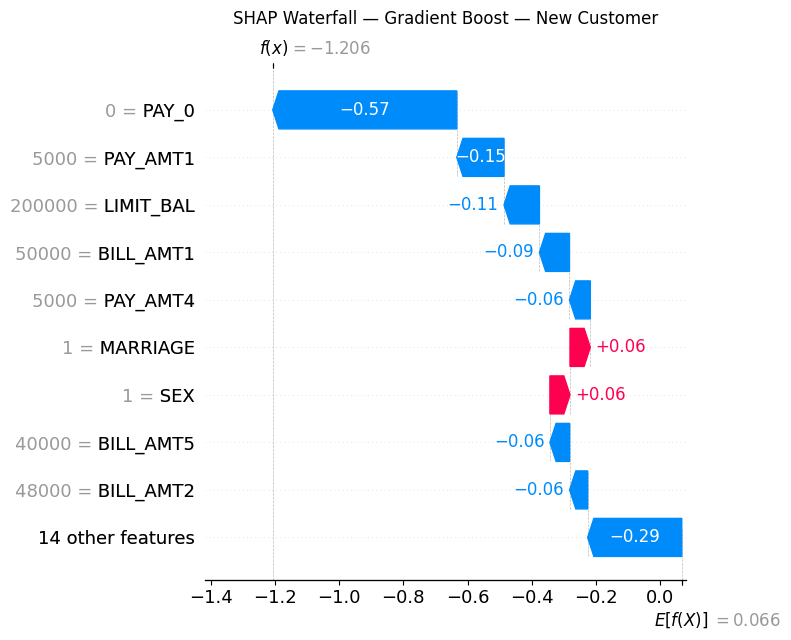


Top feature contributions (Gradient Boost):


,Feature,Value,SHAP_Value
5,PAY_0,0,-0.572761
17,PAY_AMT1,5000,-0.146867
0,LIMIT_BAL,200000,-0.110220
11,BILL_AMT1,50000,-0.093495
20,PAY_AMT4,5000,-0.064855
3,MARRIAGE,1,0.063202
1,SEX,1,0.062518
15,BILL_AMT5,40000,-0.061293
12,BILL_AMT2,48000,-0.056151
19,PAY_AMT3,5000,-0.055695



SHAP EXPLANATION — Random Forest


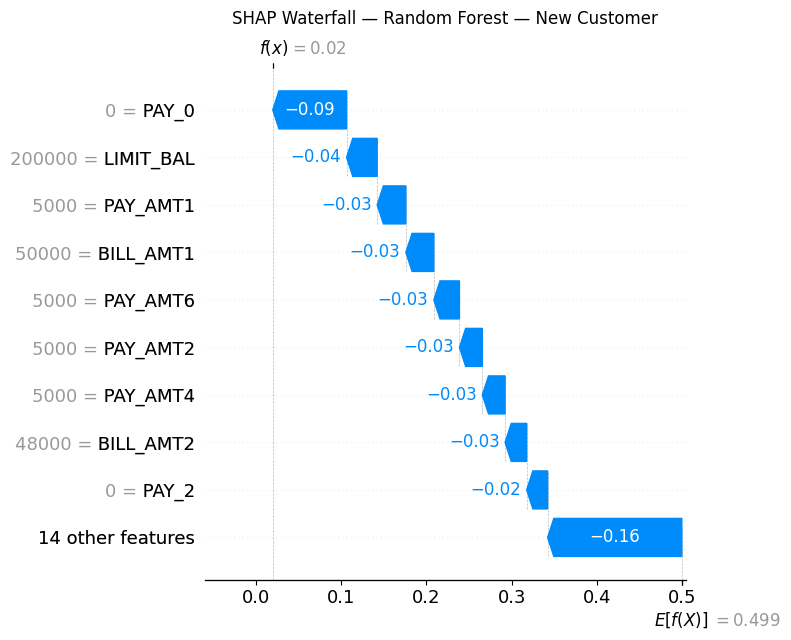


Top feature contributions (Random Forest):


,Feature,Value,SHAP_Value
5,PAY_0,0,-0.086493
0,LIMIT_BAL,200000,-0.035890
17,PAY_AMT1,5000,-0.033604
11,BILL_AMT1,50000,-0.032762
22,PAY_AMT6,5000,-0.030030
18,PAY_AMT2,5000,-0.026802
20,PAY_AMT4,5000,-0.026662
12,BILL_AMT2,48000,-0.025308
6,PAY_2,0,-0.024557
14,BILL_AMT4,42000,-0.023259



LIME EXPLANATION — Gradient Boosting


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but GradientBoostingClassifier was fitted with feature names
  warnings.warn(


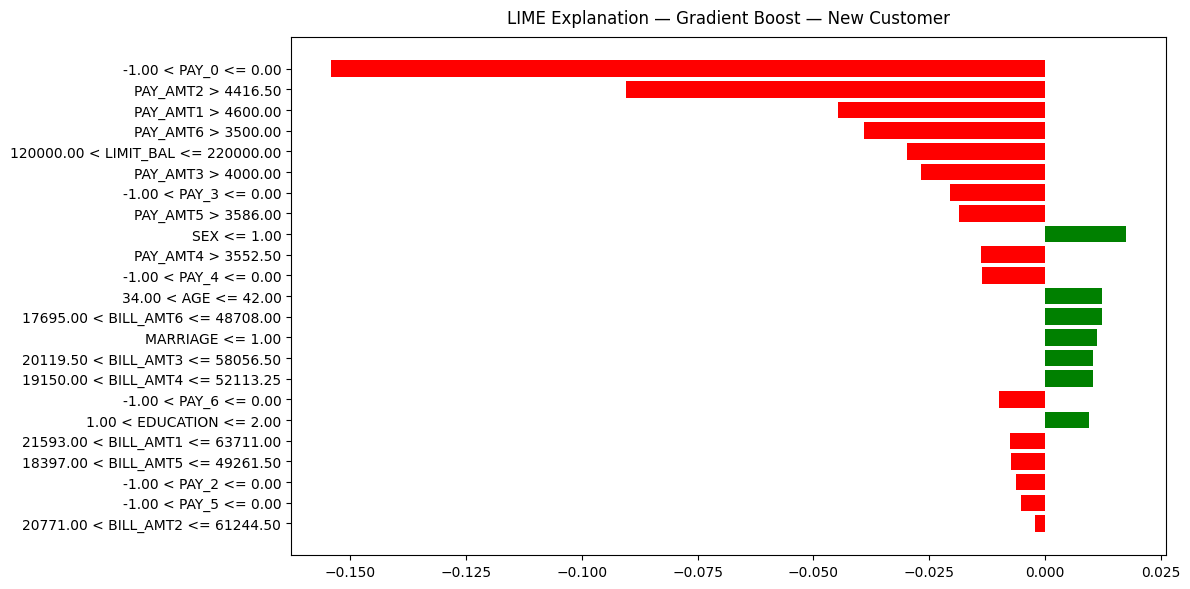

,Feature Rule,Weight
0,-1.00 < PAY_0 <= 0.00,-0.154220
1,PAY_AMT2 > 4416.50,-0.090541
2,PAY_AMT1 > 4600.00,-0.044705
3,PAY_AMT6 > 3500.00,-0.039137
4,120000.00 < LIMIT_BAL <= 220000.00,-0.029776
5,PAY_AMT3 > 4000.00,-0.026743
6,-1.00 < PAY_3 <= 0.00,-0.020579
7,PAY_AMT5 > 3586.00,-0.018563
8,SEX <= 1.00,0.017544
9,PAY_AMT4 > 3552.50,-0.013858



LIME EXPLANATION — Random Forest


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


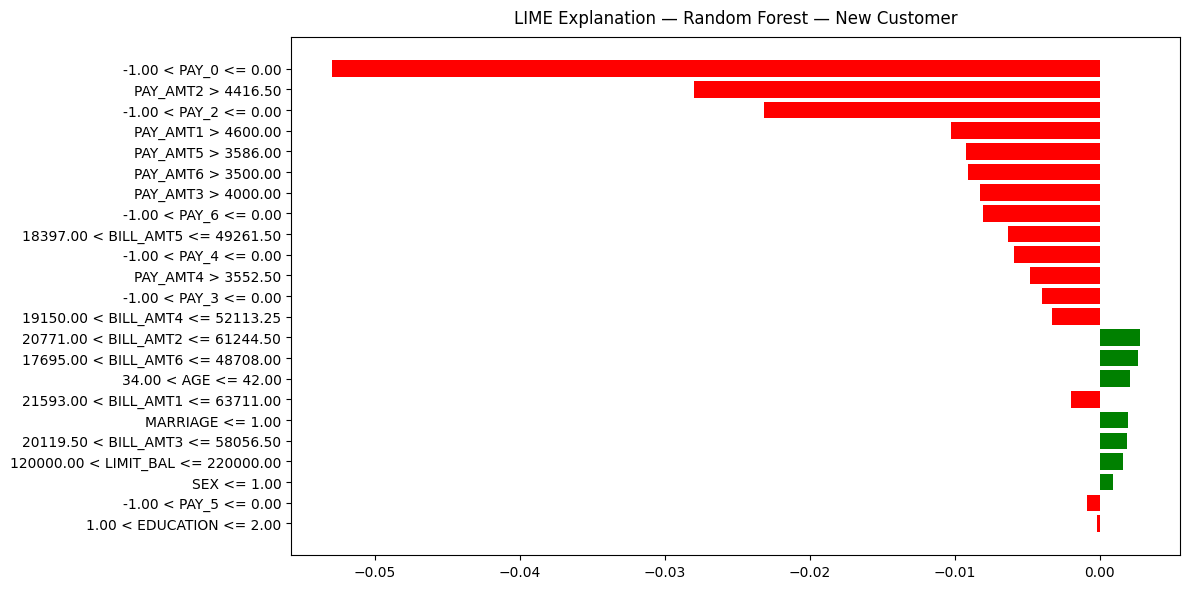

,Feature Rule,Weight
0,-1.00 < PAY_0 <= 0.00,-0.052981
1,PAY_AMT2 > 4416.50,-0.027983
2,-1.00 < PAY_2 <= 0.00,-0.023163
3,PAY_AMT1 > 4600.00,-0.010261
4,PAY_AMT5 > 3586.00,-0.009192
5,PAY_AMT6 > 3500.00,-0.009102
6,PAY_AMT3 > 4000.00,-0.008223
7,-1.00 < PAY_6 <= 0.00,-0.008019
8,18397.00 < BILL_AMT5 <= 49261.50,-0.006325
9,-1.00 < PAY_4 <= 0.00,-0.005872


In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap

# ======================================================================
# DATA PREPARATION & DATA DICTIONARY ROUTING
# ======================================================================
input_df = pd.DataFrame([new_customer])
input_df = input_df[FEATURE_NAMES]

print("=" * 70)
print("CUSTOMER INPUT")
print("=" * 70)
for key, val in new_customer.items():
    print(f"  {key:15s}: {val}")
print()

# Safely extract operational models from memory/dictionary environment mappings
gb_model = models_dict["Gradient Boost"] if "models_dict" in locals() else gb_model
rf_model = models_dict["Random Forest"] if "models_dict" in locals() else rf_model

# Run inference predictions
risk_results = {}
for model_name, model_obj in [("Gradient Boost", gb_model), ("Random Forest", rf_model)]:
    prob = model_obj.predict_proba(input_df)[0]
    pred_class = model_obj.predict(input_df)[0]
    risk_results[model_name] = {
        "prediction": int(pred_class),
        "probability_default": float(prob[1]),
        "probability_no_default": float(prob[0]),
    }

print("=" * 70)
print("RISK PREDICTIONS")
print("=" * 70)
for model_name, result in risk_results.items():
    label = "DEFAULT" if result["prediction"] == 1 else "NO DEFAULT"
    flag = "🔴 HIGH RISK" if result["probability_default"] >= 0.5 else (
        "🟡 MODERATE RISK" if result["probability_default"] >= 0.3 else "🟢 LOW RISK"
    )
    print(f"\n  {model_name}:")
    print(f"    Prediction:           {label}")
    print(f"    Default Probability:  {result['probability_default']:.4f}")
    print(f"    Risk Flag:            {flag}")
print()


# ======================================================================
# SHAP EXPLANATION — Gradient Boosting
# ======================================================================
print("=" * 70)
print("SHAP EXPLANATION — Gradient Boosting")
print("=" * 70)

gb_input_shap = gb_explainer.shap_values(input_df)

# Handle potential nested matrix wrapper output configurations inside tree architectures
if hasattr(gb_input_shap, "values"):
    gb_matrix = gb_input_shap.values
else:
    gb_matrix = gb_input_shap

# Extract flat array profile matrix tracking structures
gb_values_flat = gb_matrix[0] if len(gb_matrix.shape) == 2 else gb_matrix

shap_explanation_gb = shap.Explanation(
    values=gb_values_flat,
    base_values=float(gb_explainer.expected_value),
    data=input_df.iloc[0].values,
    feature_names=FEATURE_NAMES,
)

plt.figure(figsize=(12, 6))
shap.waterfall_plot(shap_explanation_gb, show=False)
plt.title("SHAP Waterfall — Gradient Boost — New Customer", fontsize=12, pad=10)
plt.tight_layout()
plt.show()

gb_contrib = pd.DataFrame({
    "Feature": FEATURE_NAMES,
    "Value": input_df.iloc[0].values,
    "SHAP_Value": gb_values_flat,
}).sort_values("SHAP_Value", key=abs, ascending=False)
print("\nTop feature contributions (Gradient Boost):")
display(gb_contrib)


# ======================================================================
# SHAP EXPLANATION — Random Forest (FIXED)
# ======================================================================
print()
print("=" * 70)
print("SHAP EXPLANATION — Random Forest")
print("=" * 70)

rf_input_shap_raw = rf_explainer.shap_values(input_df)

# Select positive classification category dimension wrapper [Class 1]
rf_input_shap = rf_input_shap_raw[1] if isinstance(rf_input_shap_raw, list) else rf_input_shap_raw

if hasattr(rf_input_shap, "values"):
    rf_matrix = rf_input_shap.values
else:
    rf_matrix = rf_input_shap

# CRITICAL GEOMETRIC CONVERSION FLATTENING PIPELINE FOR WATERFALL EXECUTION
if len(rf_matrix.shape) == 3:
    rf_values_flat = rf_matrix[0, :, 1]
elif len(rf_matrix.shape) == 2:
    rf_values_flat = rf_matrix[0, :] if rf_matrix.shape[0] == 1 else rf_matrix[:, 1]
else:
    rf_values_flat = rf_matrix

# Parse localized atomic baseline expected markers safely
if isinstance(rf_explainer.expected_value, (list, np.ndarray)) and len(rf_explainer.expected_value) > 1:
    rf_base = rf_explainer.expected_value[1]
else:
    rf_base = rf_explainer.expected_value

shap_explanation_rf = shap.Explanation(
    values=rf_values_flat,          # Clean single-dimensional array tracking
    base_values=float(rf_base),     # Strict atomic floating variable type specification
    data=input_df.iloc[0].values,
    feature_names=FEATURE_NAMES,
)

plt.figure(figsize=(12, 6))
shap.waterfall_plot(shap_explanation_rf, show=False)
plt.title("SHAP Waterfall — Random Forest — New Customer", fontsize=12, pad=10)
plt.tight_layout()
plt.show()

rf_contrib = pd.DataFrame({
    "Feature": FEATURE_NAMES,
    "Value": input_df.iloc[0].values,
    "SHAP_Value": rf_values_flat,
}).sort_values("SHAP_Value", key=abs, ascending=False)
print("\nTop feature contributions (Random Forest):")
display(rf_contrib)


# ======================================================================
# LIME EXPLANATION — Gradient Boosting (FIXED)
# ======================================================================
print()
print("=" * 70)
print("LIME EXPLANATION — Gradient Boosting")
print("=" * 70)

lime_exp_gb = lime_explainer.explain_instance(
    input_df.iloc[0].values,
    gb_model.predict_proba,
    num_features=len(FEATURE_NAMES)
)
fig = lime_exp_gb.as_pyplot_figure()
fig.set_size_inches(12, 6)
plt.title("LIME Explanation — Gradient Boost — New Customer", fontsize=12, pad=10)
plt.tight_layout()
plt.show()

lime_gb_df = pd.DataFrame(lime_exp_gb.as_list(), columns=["Feature Rule", "Weight"])
display(lime_gb_df)


# ======================================================================
# LIME EXPLANATION — Random Forest (FIXED)
# ======================================================================
print()
print("=" * 70)
print("LIME EXPLANATION — Random Forest")
print("=" * 70)

lime_exp_rf = lime_explainer.explain_instance(
    input_df.iloc[0].values,
    rf_model.predict_proba,
    num_features=len(FEATURE_NAMES)
)
fig = lime_exp_rf.as_pyplot_figure()
fig.set_size_inches(12, 6)
plt.title("LIME Explanation — Random Forest — New Customer", fontsize=12, pad=10)
plt.tight_layout()
plt.show()

lime_rf_df = pd.DataFrame(lime_exp_rf.as_list(), columns=["Feature Rule", "Weight"])
display(lime_rf_df)

In [29]:
from google.colab import files
files.download('trained_models.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>